# Load data & Projektverständnis

## 🧠 PROJEKTVERSTÄNDNIS

### 📌 Business Problem
TravelTide möchte ein personalisiertes Rewards-Programm entwickeln, um die Kundenbindung zu erhöhen

### Ziel ist:
Kunden zur Anmeldung motivieren

#### passende Perks (Vorteile) anbieten:
- free hotel meal
- free checked bag
- no cancellation fees
- exclusive discounts
- 1 night free hotel

####  🎯 Data Science Ziel
- Kundenverhalten analysieren
- Segmente identifizieren
- für jeden Kunden den attraktivsten Perk bestimmen

#### 🧩 Hypothese
Kunden zeigen unterschiedliche Präferenzen → Segmentierung ist sinnvoll

#### 📊 Datenbasis
- Session-Daten (bereits gefiltert):
- nur aktive User (>7 Sessions)
- Datum > 04.01.2024

#### Ziel-Ebene: Customer-Level
Aktuelle Daten: Session-Level
👉 → später aggregieren

## import libraries

In [1]:
# import libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from functools import reduce
from pandas.core.methods import describe

## load_data

In [2]:
# load sql-files
sessions = pd.read_csv("../01_data/sql_filtered/temp_sessions_aktiv.csv")
flights = pd.read_csv("../01_data/sql_filtered/temp_flights_aktiv.csv")
hotels = pd.read_csv("../01_data/sql_filtered/temp_hotels_aktiv.csv")
users = pd.read_csv("../01_data/sql_filtered/temp_users_aktiv_gefiltert.csv")

# EDA - DATA UNDERSTANDING (Diagramme, Prüfung fehlender Werte, erste Einblicke)

In [3]:
# check headers
for name, df in {
    "sessions": sessions,
    "flights": flights,
    "hotels": hotels,
    "users": users
}.items():
    print(f"--- {name.upper()} ---")
    display(df.head())
    #display(df.info())
    #display(df.describe(include="all"))
    #print(df.isna().sum())
    print("\n")

--- SESSIONS ---


,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,94883-ec6cc8bb0a7441739923714e2f75bceb,94883,NaN,2023-01-10 12:20:00.000000,2023-01-10 12:20:14.000000,False,False,NaN,NaN,False,False,2,False
1,94883-a7021e0950814faa8fb9045613065658,94883,NaN,2023-01-19 20:06:00.000000,2023-01-19 20:06:44.000000,False,False,NaN,NaN,False,False,6,False
2,94883-2f84fec9280b4d80aa14803df2246c5f,94883,NaN,2023-01-23 21:47:00.000000,2023-01-23 21:47:58.000000,False,True,NaN,0.1,False,False,8,False
3,94883-f649e048680a4119afc2ef90eec3c7f0,94883,NaN,2023-01-26 22:25:00.000000,2023-01-26 22:25:16.000000,False,False,NaN,NaN,False,False,2,False
4,94883-703b810910084bacab496e054ef0f1de,94883,NaN,2023-02-17 10:08:00.000000,2023-02-17 10:08:31.000000,False,False,NaN,NaN,False,False,4,False




--- FLIGHTS ---


,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,101486-1015905607d74b15954bfd4ac7029ef3,TCM,edmonton,YED,1,True,2023-06-10 10:00:00.000000,2023-06-14 10:00:00.000000,0,United Airlines,53.667,-113.467,189.91
1,101961-19f641633ebc442799662326f0b4dfa0,BOS,new york,LGA,1,True,2023-05-05 11:00:00.000000,2023-05-09 11:00:00.000000,0,Allegiant Air,40.640,-73.779,49.67
2,101961-29a8ff7c9910469c959fffa60215cf78,BOS,montreal,YHU,1,True,2023-02-08 07:00:00.000000,2023-02-13 07:00:00.000000,1,United Airlines,45.517,-73.417,77.02
3,101961-836fd88487d240baa4402c8e4c6f188c,BOS,seattle,BFI,1,True,2023-03-16 07:00:00.000000,2023-03-21 07:00:00.000000,1,Kenmore Air,47.530,-122.302,769.50
4,101961-c4c922fbc83342779565d249ee5e6bf7,BOS,charlotte,CLT,1,True,2023-06-27 11:00:00.000000,2023-07-05 11:00:00.000000,0,JetBlue Airways,35.214,-80.943,216.57




--- HOTELS ---


,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,101486-1015905607d74b15954bfd4ac7029ef3,Crowne Plaza - edmonton,3,1,2023-06-10 13:12:24.030000,2023-06-14 11:00:00.000000,253
1,101486-6759c5dd49a1457d916bb2bbf48c3115,Banyan Tree - montreal,5,2,2023-06-24 11:00:00.000000,2023-06-29 11:00:00.000000,144
2,101961-19f641633ebc442799662326f0b4dfa0,Conrad - new york,3,1,2023-05-05 13:22:30.720000,2023-05-09 11:00:00.000000,165
3,101961-29a8ff7c9910469c959fffa60215cf78,Rosewood - montreal,4,1,2023-02-08 09:30:00.990000,2023-02-12 11:00:00.000000,197
4,101961-836fd88487d240baa4402c8e4c6f188c,Extended Stay - seattle,4,1,2023-03-16 14:00:14.670000,2023-03-21 11:00:00.000000,132




--- USERS ---


,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10


In [4]:
# check size, Dtypes, NonNull Counts
for name, df in {
    "sessions": sessions,
    "flights": flights,
    "hotels": hotels,
    "users": users
}.items():
    print(f"--- {name.upper()} ---")
    #display(df.head())
    display(df.info())
    #display(df.describe(include="all"))
    print(df.isna().sum()) #Anzahl fehlender Werte
    print("\n")


--- SESSIONS ---
<class 'pandas.DataFrame'>
RangeIndex: 47436 entries, 0 to 47435
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              47436 non-null  str    
 1   user_id                 47436 non-null  int64  
 2   trip_id                 16066 non-null  str    
 3   session_start           47436 non-null  str    
 4   session_end             47436 non-null  str    
 5   flight_discount         47436 non-null  bool   
 6   hotel_discount          47436 non-null  bool   
 7   flight_discount_amount  7971 non-null   float64
 8   hotel_discount_amount   6015 non-null   float64
 9   flight_booked           47436 non-null  bool   
 10  hotel_booked            47436 non-null  bool   
 11  page_clicks             47436 non-null  int64  
 12  cancellation            47436 non-null  bool   
dtypes: bool(5), float64(2), int64(2), str(4)
memory usage: 3.1 MB


None

session_id                    0
user_id                       0
trip_id                   31370
session_start                 0
session_end                   0
flight_discount               0
hotel_discount                0
flight_discount_amount    39465
hotel_discount_amount     41421
flight_booked                 0
hotel_booked                  0
page_clicks                   0
cancellation                  0
dtype: int64


--- FLIGHTS ---
<class 'pandas.DataFrame'>
RangeIndex: 13193 entries, 0 to 13192
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  13193 non-null  str    
 1   origin_airport           13193 non-null  str    
 2   destination              13193 non-null  str    
 3   destination_airport      13193 non-null  str    
 4   seats                    13193 non-null  int64  
 5   return_flight_booked     13193 non-null  bool   
 6   departure_time    

None

trip_id                      0
origin_airport               0
destination                  0
destination_airport          0
seats                        0
return_flight_booked         0
departure_time               0
return_time                573
checked_bags                 0
trip_airline                 0
destination_airport_lat      0
destination_airport_lon      0
base_fare_usd                0
dtype: int64


--- HOTELS ---
<class 'pandas.DataFrame'>
RangeIndex: 13772 entries, 0 to 13771
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   trip_id             13772 non-null  str  
 1   hotel_name          13772 non-null  str  
 2   nights              13772 non-null  int64
 3   rooms               13772 non-null  int64
 4   check_in_time       13772 non-null  str  
 5   check_out_time      13772 non-null  str  
 6   hotel_per_room_usd  13772 non-null  int64
dtypes: int64(3), str(4)
memory usage: 753.3 KB

None

trip_id               0
hotel_name            0
nights                0
rooms                 0
check_in_time         0
check_out_time        0
hotel_per_room_usd    0
dtype: int64


--- USERS ---
<class 'pandas.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5782 non-null   int64  
 1   birthdate         5782 non-null   str    
 2   gender            5782 non-null   str    
 3   married           5782 non-null   bool   
 4   has_children      5782 non-null   bool   
 5   home_country      5782 non-null   str    
 6   home_city         5782 non-null   str    
 7   home_airport      5782 non-null   str    
 8   home_airport_lat  5782 non-null   float64
 9   home_airport_lon  5782 non-null   float64
 10  sign_up_date      5782 non-null   str    
dtypes: bool(2), float64(2), int64(1), str(6)
memory usage: 418.0 KB


None

user_id             0
birthdate           0
gender              0
married             0
has_children        0
home_country        0
home_city           0
home_airport        0
home_airport_lat    0
home_airport_lon    0
sign_up_date        0
dtype: int64




### Resultat: Analyse der Missing‑Value‑Struktur in Sessions, Flights, Hotels und Users

Die Verteilung der fehlenden Werte zeigt ein konsistentes Muster, das wichtige Hinweise auf Datenqualität, Plattformlogik und spätere Aggregationsschritte liefert. Die folgende Zusammenfassung ordnet die Befunde systematisch ein und leitet die relevanten Konsequenzen für weitere Analysen ab.

#### Sessions als Hauptquelle struktureller Missing Values

##### Beobachtungen
- `trip_id`: **31.370 fehlend**
- `flight_discount_amount`: **39.465 fehlend**
- `hotel_discount_amount`: **41.421 fehlend**

##### Interpretation
- Das Fehlen von `trip_id` in rund zwei Dritteln aller Sessions deutet darauf hin, dass der Großteil der Sitzungen reine **Browsing‑Aktivität** ohne gestartete Reise darstellt. Nur 16.066 Sessions sind einer tatsächlichen Reise zugeordnet.
- Fehlende Werte bei `flight_discount_amount` und `hotel_discount_amount` sind **logisch bedingt**: Rabatte existieren nur bei tatsächlichen Buchungen. Ein fehlender Wert bedeutet daher nicht „unbekannt“, sondern „nicht relevant“.

##### Konsequenzen
- Diese fehlenden Werte sind **strukturelle NAs** und dürfen nicht als Datenlücken interpretiert werden.
- Für spätere Analysen empfiehlt sich die Ableitung binärer Variablen:
  - `has_trip = trip_id.notna()`
  - `has_flight_discount = flight_discount_amount.notna()`
  - `has_hotel_discount = hotel_discount_amount.notna()`

#### Flights mit einem klar abgegrenzten Missing‑Value‑Typ

##### Beobachtung
- `return_time`: **573 fehlend**

##### Interpretation
- Fehlende Rückflugzeiten entsprechen **One‑Way‑Trips** und stellen keinen Datenfehler dar.

##### Konsequenz
- Ableitung einer zusätzlichen Variable:
  - `is_one_way = return_time.isna()`

#### Hotels ohne fehlende Werte

##### Interpretation
- Die Hotelbuchungen sind vollständig.
- Frühere Auffälligkeiten bei `nights` resultierten nicht aus Missing Values, sondern aus der Logik der Zeitstempel.

#### Users ohne fehlende Werte

##### Interpretation
- Nutzerprofile liegen vollständig vor und bilden eine stabile Grundlage für demografische Analysen.

#### Bedeutung der Missing‑Value‑Analyse für die weiteren Schritte

Die Unterscheidung zwischen echten Datenlücken und logisch bedingten NAs ist entscheidend:

- Das Entfernen von Sessions ohne `trip_id` würde rund **66 % der Nutzeraktivität** eliminieren.
- Die Interpretation fehlender Rabattbeträge als „Datenfehler“ würde die Rabattlogik verfälschen.
- Die Behandlung fehlender `return_time`‑Werte als Fehler würde One‑Way‑Trips unzulässig ausschließen.

Eine korrekte Einordnung der Missing Values ist daher Voraussetzung für valide Nutzer‑, Buchungs‑ und Verhaltensanalysen.

#### Empfohlene Vorverarbeitungsschritte

```python
sessions["has_trip"] = sessions["trip_id"].notna()
sessions["has_flight_discount"] = sessions["flight_discount_amount"].notna()
sessions["has_hotel_discount"] = sessions["hotel_discount_amount"].notna()

flights["is_one_way"] = flights["return_time"].isna()
```

Diese Variablen bilden die strukturellen NAs korrekt ab und schaffen eine robuste Grundlage für weitere Auswertungen.

#### Ausgangslage für die anschließende Nutzer‑Demografie

- **Users**: vollständig
- **Sessions**: strukturelle NAs korrekt interpretiert
- **Flights**: One‑Way‑Trips identifiziert
- **Hotels**: vollständig und bereinigt

Damit ist die Datenbasis konsistent vorbereitet, um in die Analyse der Nutzer‑Demografie einzusteigen.

### Struktur der NaN werte in neuen Spalten abbilden

In [5]:
sessions["has_trip"] = sessions["trip_id"].notna()

In [6]:
sessions["has_flight_discount"] = sessions["flight_discount_amount"].notna()    #PotentialUserFeaturerColumn

In [7]:
sessions["has_hotel_discount"] = sessions["hotel_discount_amount"].notna()      #PotentialUserFeaturerColumn


In [8]:
flights["is_one_way"] = flights["return_time"].isna()                           #PotentialUserFeaturerColumn

### Datumsformate korrekt konvertieren & PotentialUserFeaturerColumn

In [9]:
# SESSIONS – session_start, session_end

# Diese beiden Spalten sind Strings → in echte Timestamps umwandeln
sessions["session_start"] = pd.to_datetime(sessions["session_start"], errors="coerce")
sessions["session_end"]   = pd.to_datetime(sessions["session_end"], errors="coerce")

# Session-Dauer berechnen (wird später nützlich)
sessions["session_duration_calc"] = sessions["session_end"] - sessions["session_start"] #PotentialUserFeaturerColumn  erledigt

In [10]:
# FLIGHTS – departure_time, return_time

# Beide Spalten enthalten Datums-/Zeitangaben, aber als Strings
flights["departure_time"] = pd.to_datetime(flights["departure_time"], errors="coerce")
flights["return_time"]    = pd.to_datetime(flights["return_time"], errors="coerce")

# Aufenthaltsdauer (falls return_time vorhanden)
flights["flight_duration_calc"] = flights["return_time"] - flights["departure_time"]    #PotentialUserFeaturerColumn

In [11]:
# HOTELS – check_in_time, check_out_time

hotels["check_in_time"]  = pd.to_datetime(hotels["check_in_time"], errors="coerce")
hotels["check_out_time"] = pd.to_datetime(hotels["check_out_time"], errors="coerce")

# Aufenthaltsdauer berechnen
hotels["stay_duration_calc"] = hotels["check_out_time"] - hotels["check_in_time"]       #PotentialUserFeaturerColumn

In [12]:
# USERS – birthdate, sign_up_date

users["birthdate"]    = pd.to_datetime(users["birthdate"], errors="coerce")
users["sign_up_date"] = pd.to_datetime(users["sign_up_date"], errors="coerce")

# Alter berechnen
users["age_years_cal"] = (pd.Timestamp("today") - users["birthdate"]).dt.days // 365       #PotentialUserFeaturerColumn

# Kundenalter in Monaten
users["customer_age_months_calc"] = (
    (pd.Timestamp("today") - users["sign_up_date"]) / pd.Timedelta(days=30)
).astype(int)                                                                               #PotentialUserFeaturerColumn

In [13]:
# Check: Korrekturen dtypes
sessions.dtypes
flights.dtypes
hotels.dtypes
users.dtypes

user_id                              int64
birthdate                   datetime64[us]
gender                                 str
married                               bool
has_children                          bool
home_country                           str
home_city                              str
home_airport                           str
home_airport_lat                   float64
home_airport_lon                   float64
sign_up_date                datetime64[us]
age_years_cal                        int64
customer_age_months_calc             int64
dtype: object

In [14]:
# Check: Korrekturen statistische Basiskennzahlen
for name, df in {
    "sessions": sessions,
    "flights": flights,
    "hotels": hotels,
    "users": users
}.items():
    print(f"--- {name.upper()} ---")
    #display(df.head())
    #display(df.info())
    display(df.describe(include="all"))
    #print(df.isna().sum()) #Anzahl fehlender Werte
    print("\n")


--- SESSIONS ---


,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation,has_trip,has_flight_discount,has_hotel_discount,session_duration_calc
count,47436,47436.000000,16066,47436,47436,47436,47436,7971.000000,6015.000000,47436,47436,47436.000000,47436,47436,47436,47436,47436
unique,47436,NaN,15484,NaN,NaN,2,2,NaN,NaN,2,2,NaN,2,2,2,2,NaN
top,94883-ec6cc8bb0a7441739923714e2f75bceb,NaN,106907-718c9cf6c29245fa9b2b31893833ac2c,NaN,NaN,False,False,NaN,NaN,False,False,NaN,False,False,False,False,NaN
freq,1,NaN,2,NaN,NaN,38876,40832,NaN,NaN,33661,33079,NaN,46847,31370,39465,41421,NaN
mean,NaN,547497.276246,NaN,2023-03-22 03:26:47.802196,2023-03-22 03:29:55.361977,NaN,NaN,0.139725,0.112211,NaN,NaN,17.598153,NaN,NaN,NaN,NaN,0 days 00:03:07.559780
min,NaN,94883.000000,NaN,2023-01-05 00:39:00,2023-01-05 00:42:05,NaN,NaN,0.050000,0.050000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0 days 00:00:06
25%,NaN,519383.000000,NaN,2023-02-06 19:41:30,2023-02-06 19:42:08,NaN,NaN,0.100000,0.050000,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,0 days 00:00:45
50%,NaN,542095.000000,NaN,2023-03-09 21:27:00,2023-03-09 21:29:43.500000,NaN,NaN,0.100000,0.100000,NaN,NaN,13.000000,NaN,NaN,NaN,NaN,0 days 00:01:36
75%,NaN,575823.000000,NaN,2023-04-28 22:23:30,2023-04-28 22:25:14.750000,NaN,NaN,0.200000,0.150000,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,0 days 00:02:42
max,NaN,844489.000000,NaN,2023-07-28 19:58:52,2023-07-28 20:08:52,NaN,NaN,0.600000,0.450000,NaN,NaN,566.000000,NaN,NaN,NaN,NaN,0 days 02:00:00




--- FLIGHTS ---


,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,is_one_way,flight_duration_calc
count,13193,13193,13193,13193,13193.000000,13193,13193,12620,13193.000000,13193,13193.000000,13193.000000,13193.000000,13193,12620
unique,13193,159,124,181,NaN,2,NaN,NaN,NaN,174,NaN,NaN,NaN,2,NaN
top,101486-1015905607d74b15954bfd4ac7029ef3,LGA,new york,JFK,NaN,True,NaN,NaN,NaN,Delta Air Lines,NaN,NaN,NaN,False,NaN
freq,1,835,1868,944,NaN,12620,NaN,NaN,NaN,2013,NaN,NaN,NaN,12620,NaN
mean,NaN,NaN,NaN,NaN,1.200106,NaN,2023-04-11 10:41:27.500947,2023-04-15 16:40:21.299524,0.584477,NaN,38.708329,-90.471100,489.114071,NaN,4 days 06:21:27.099841
min,NaN,NaN,NaN,NaN,1.000000,NaN,2023-01-09 11:00:00,2023-01-11 11:00:00,0.000000,NaN,-37.008000,-157.927000,2.410000,NaN,0 days 00:00:00
25%,NaN,NaN,NaN,NaN,1.000000,NaN,2023-02-16 07:00:00,2023-02-19 15:00:00,0.000000,NaN,33.942000,-112.383000,198.600000,NaN,2 days 00:00:00
50%,NaN,NaN,NaN,NaN,1.000000,NaN,2023-03-23 07:00:00,2023-03-26 14:30:00,1.000000,NaN,39.872000,-87.752000,377.820000,NaN,3 days 00:00:00
75%,NaN,NaN,NaN,NaN,1.000000,NaN,2023-05-19 13:00:00,2023-05-23 12:00:00,1.000000,NaN,42.409000,-75.669000,590.590000,NaN,5 days 00:00:00
max,NaN,NaN,NaN,NaN,8.000000,NaN,2024-07-16 07:00:00,2024-07-29 07:00:00,8.000000,NaN,55.972000,174.792000,14466.330000,NaN,35 days 00:00:00




--- HOTELS ---


,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,stay_duration_calc
count,13772,13772,13772.000000,13772.000000,13772,13772,13772.000000,13772
unique,13772,954,NaN,NaN,NaN,NaN,NaN,NaN
top,101486-1015905607d74b15954bfd4ac7029ef3,Conrad - new york,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,115,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,3.616250,1.195396,2023-04-05 18:44:13.492212,2023-04-09 20:58:48.899215,178.147401,4 days 02:14:35.407003
min,NaN,NaN,-2.000000,1.000000,2023-01-08 11:00:00,2023-01-10 11:00:00,17.000000,-2 days +14:53:17.925000
25%,NaN,NaN,1.000000,1.000000,2023-02-16 09:59:15.157500,2023-02-20 11:00:00,99.000000,1 days 20:19:16.736250
50%,NaN,NaN,2.000000,1.000000,2023-03-22 11:00:00,2023-03-26 11:00:00,148.000000,2 days 22:42:01.935000
75%,NaN,NaN,5.000000,1.000000,2023-05-15 12:20:50.043750,2023-05-19 11:00:00,223.000000,5 days 00:00:00
max,NaN,NaN,43.000000,4.000000,2024-07-17 00:33:41.625000,2024-07-29 11:00:00,1376.000000,43 days 00:00:00




--- USERS ---


,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age_years_cal,customer_age_months_calc
count,5782.000000,5782,5782,5782,5782,5782,5782,5782,5782.000000,5782.000000,5782,5782.000000,5782.000000
unique,NaN,NaN,3,2,2,2,105,159,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,F,False,False,usa,new york,LGA,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5118,3226,3896,4808,657,348,NaN,NaN,NaN,NaN,NaN
mean,547670.236077,1982-02-22 03:35:55.517122,NaN,NaN,NaN,NaN,NaN,NaN,38.449324,-94.158017,2023-01-21 06:16:33.704600,43.644933,38.620201
min,94883.000000,1935-05-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,21.316000,-157.927000,2022-02-07 00:00:00,19.000000,35.000000
25%,519413.750000,1974-09-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,33.818000,-112.289250,2023-01-09 00:00:00,37.000000,38.000000
50%,542279.500000,1981-10-25 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,39.175000,-90.035000,2023-01-20 00:00:00,44.000000,39.000000
75%,576215.500000,1989-03-17 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,42.276000,-79.370000,2023-02-06 00:00:00,51.000000,39.000000
max,844489.000000,2006-12-28 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,61.251000,-63.499000,2023-05-18 00:00:00,90.000000,50.000000


In [15]:
# Check: Korrekturen statistische Basiskennzahlen
for name, df in {
    "sessions": sessions,
    "flights": flights,
    "hotels": hotels,
    "users": users
}.items():
    print(f"--- {name.upper()} ---")
    #display(df.head())
    #display(df.info())
    #display(df.describe(include="all"))
    #print(df.isna().sum())  #Anzahl fehlender Werte
    print(df.nunique())
    print("\n")


--- SESSIONS ---
session_id                47436
user_id                    5782
trip_id                   15484
session_start             41150
session_end               47296
flight_discount               2
hotel_discount                2
flight_discount_amount       12
hotel_discount_amount         9
flight_booked                 2
hotel_booked                  2
page_clicks                 199
cancellation                  2
has_trip                      2
has_flight_discount           2
has_hotel_discount            2
session_duration_calc      1098
dtype: int64


--- FLIGHTS ---
trip_id                    13193
origin_airport               159
destination                  124
destination_airport          181
seats                          8
return_flight_booked           2
departure_time              2409
return_time                 2422
checked_bags                   8
trip_airline                 174
destination_airport_lat      124
destination_airport_lon      124
base_fare_us

### Sessions pro User

In [16]:
# Anzahl der Sessions pro User berechnen

# gruppieren nach user_id und zählen die Session-IDs.
sessions_per_user = (
    sessions
    .groupby("user_id")["session_id"]
    .count()
    .reset_index()
)

# Spalte umbenennen für Klarheit
sessions_per_user.columns = ["user_id", "total_sessions"]       #PotentialUserFeaturerColumn

# Überblick über die Verteilung
sessions_per_user.describe()

,user_id,total_sessions
count,5782.000000,5782.000000
mean,547670.236077,8.204082
std,64035.394540,0.459986
min,94883.000000,8.000000
25%,519413.750000,8.000000
50%,542279.500000,8.000000
75%,576215.500000,8.000000
max,844489.000000,12.000000


#### Interpretation: Sessions pro User

##### Die Kennzahlen beschreiben die Verteilung der Anzahl an Sessions pro Nutzer.
Die Spalten stehen für:
- `user_id` (Index, ignorierbar für die Interpretation)
- `total_sessions` (Anzahl Sessions pro User)

**count = 5782**
Es gibt 5.782 Nutzer im gefilterten Datensatz. Für jeden Nutzer wurde die Anzahl seiner Sessions berechnet.

**mean = 8.20**
Ein durchschnittlicher Nutzer hat **etwa 8 Sessions** im betrachteten Zeitraum.
Das ist ein sehr enger Wert und zeigt, dass die meisten Nutzer ähnlich aktiv sind.

**std = 0.46**
Die Standardabweichung ist extrem gering.
Das bedeutet: Fast alle Nutzer haben **genau 8 Sessions**, nur wenige haben mehr.

**min = 8**
Der niedrigste Wert ist **8 Sessions**.
Das ergibt Sinn, da du in SQL bereits gefiltert hast: *nur Nutzer mit mehr als 7 Sessions*.

**25% / 50% / 75% = 8 / 8 / 8**
Die Quartile liegen alle bei **8 Sessions**.
Das bestätigt: Die Verteilung ist extrem konzentriert – fast alle Nutzer haben exakt 8 Sessions.

**max = 12**
Der aktivste Nutzer hat **12 Sessions**.
Das ist nur leicht über dem Durchschnitt und zeigt, dass es keine extremen Vielnutzer gibt.

**Fazit:**
Die Session‑Anzahl ist stark durch deinen SQL‑Filter geprägt. Die meisten Nutzer haben exakt 8 Sessions, wenige haben 9–12. Dieses Feature hat daher **sehr geringe Varianz** und wird für spätere Segmentierung vermutlich **wenig trennscharf** sein. Es kann sinnvoll sein, später zusätzliche Session‑basierte Features zu entwickeln (z. B. Klickverhalten, Buchungsrate pro Session), um mehr Variation zu erzeugen.


### sessions Verhalten (Clicks, Fligths booked, Hotels booked)

In [17]:
sessions["page_clicks"].describe()
sessions["flight_booked"].mean()
sessions["hotel_booked"].mean()
sessions.columns

Index(['session_id', 'user_id', 'trip_id', 'session_start', 'session_end',
       'flight_discount', 'hotel_discount', 'flight_discount_amount',
       'hotel_discount_amount', 'flight_booked', 'hotel_booked', 'page_clicks',
       'cancellation', 'has_trip', 'has_flight_discount', 'has_hotel_discount',
       'session_duration_calc'],
      dtype='str')

### sessions Verhalten durchschnittliche Klicks bei Buchung vs. nicht Buchung

In [18]:
# Anzahl clicks fights_booked true vs false
sessions.groupby("flight_booked")["page_clicks"].describe()

,count,mean,std,min,25%,50%,75%,max
flight_booked,,,,,,,,
False,33661.0,12.058138,12.719875,1.0,5.0,8.0,15.0,279.0
True,13775.0,31.135898,30.712115,7.0,19.0,23.0,30.0,566.0


In [19]:
# Anzahl clicks hotel_booked true vs false
sessions.groupby("hotel_booked")["page_clicks"].describe()

,count,mean,std,min,25%,50%,75%,max
hotel_booked,,,,,,,,
False,33079.0,11.87019,12.434124,1.0,5.0,8.0,15.0,279.0
True,14357.0,30.79557,30.432705,8.0,19.0,22.0,30.0,566.0


In [20]:
# Anzahl clicks fights_booked hotels_booked true vs false
flight_clicks = sessions.groupby("flight_booked")["page_clicks"].mean()
hotel_clicks = sessions.groupby("hotel_booked")["page_clicks"].mean()

comparison = pd.DataFrame({
    "Flights": flight_clicks,
    "Hotels": hotel_clicks
})

print(comparison)

         Flights    Hotels
False  12.058138  11.87019
True   31.135898  30.79557


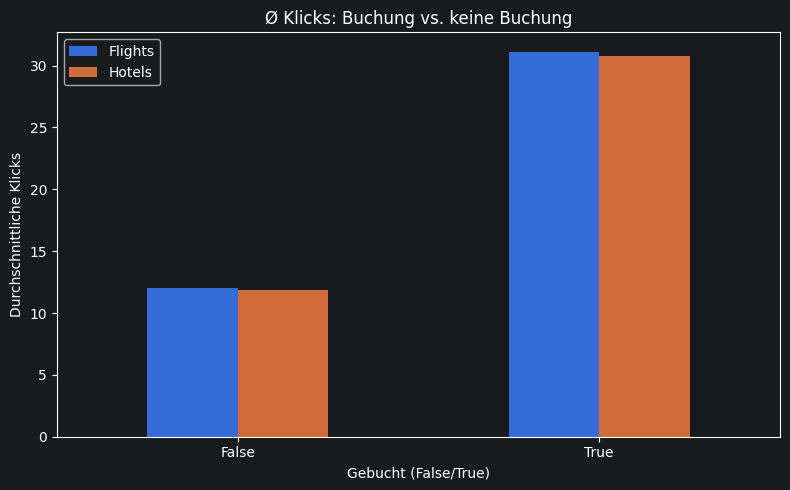

In [21]:
# plot durchschnittliche clicks vs gebucht true /false
comparison.plot(kind="bar", figsize=(8, 5))

plt.title("Ø Klicks: Buchung vs. keine Buchung")
plt.xlabel("Gebucht (False/True)")
plt.ylabel("Durchschnittliche Klicks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### session Verhalten Buchungswahrscheinlichkeit nach Anzahl der clicks by flights

In [22]:
# tbl durchschmittliche Anzahl clicks gruppiert flight_booked true/false
sessions["click_bin"] = pd.cut(
    sessions["page_clicks"],
    bins=[0, 5, 10, 20, 50, 200],
    labels=["0-5", "6-10", "11-20", "21-50", "50+"]
)

pd.crosstab(
    sessions["click_bin"],
    sessions["flight_booked"],
    normalize="index"
)

flight_booked,False,True
click_bin,,
0-5,1.000000,0.000000
6-10,0.976630,0.023370
11-20,0.639892,0.360108
21-50,0.362145,0.637855
50+,0.324009,0.675991


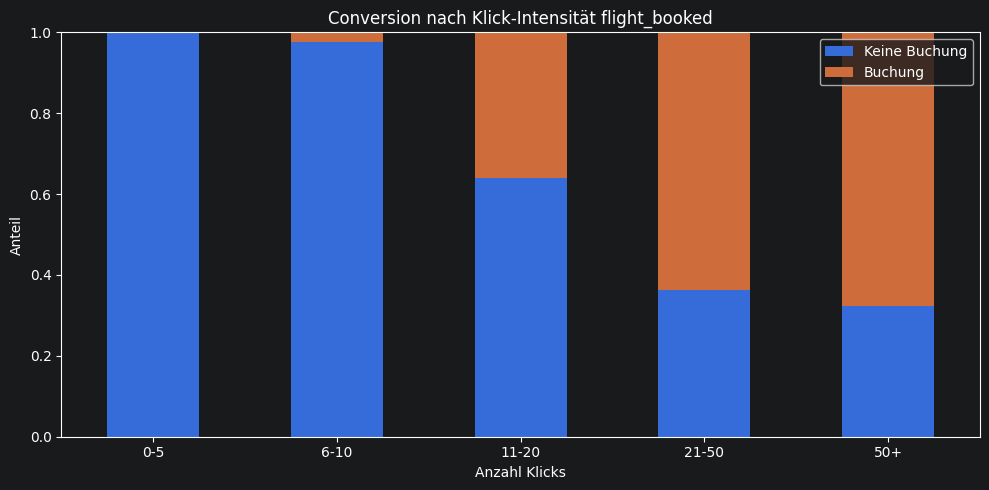

In [23]:
# plot durchschmittliche Anzahl clicks gruppiert flight_booked true/false
ct = pd.crosstab(
    sessions["click_bin"],
    sessions["flight_booked"],
    normalize="index"
)

ct.plot(kind="bar", stacked=True, figsize=(10, 5))

plt.title("Conversion nach Klick-Intensität flight_booked")
plt.xlabel("Anzahl Klicks")
plt.ylabel("Anteil")
plt.legend(["Keine Buchung", "Buchung"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

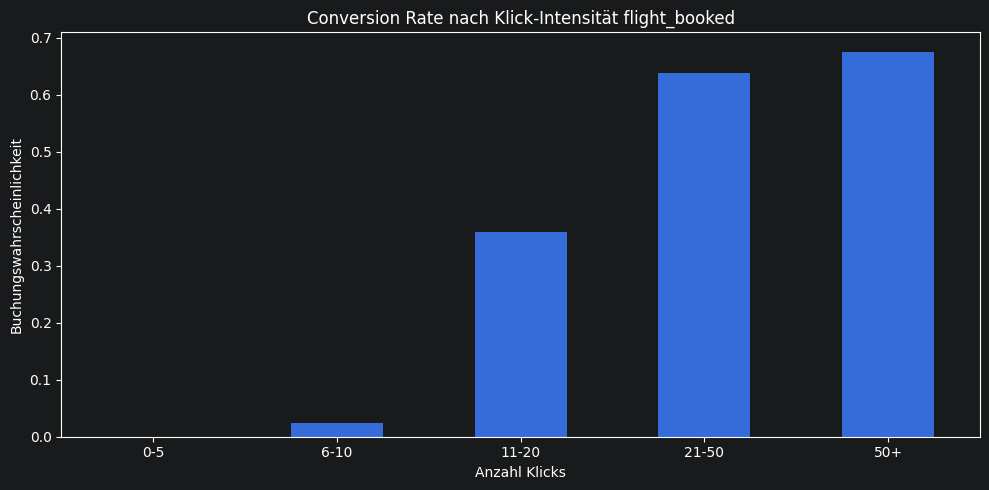

In [24]:
# plot Buchungswahrscheinlichkeit nach Anzahl durch clicks
conversion_rate = ct[True]

conversion_rate.plot(kind="bar", figsize=(10, 5))

plt.title("Conversion Rate nach Klick-Intensität flight_booked")
plt.xlabel("Anzahl Klicks")
plt.ylabel("Buchungswahrscheinlichkeit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### clicks vs booking statistischer Zusammenhang

In [25]:
# Berechnung: Chi²-Test, p-Wert, Freiheitsgrade
# Crosstab (ohne Normalisierung!)
ct_counts = pd.crosstab(
    sessions["click_bin"],
    sessions["flight_booked"]
)

# Chi²-Test
chi2, p, dof, expected = chi2_contingency(ct_counts)

print("Chi2:", chi2)
print("p-Wert:", p)
print("Freiheitsgrade:", dof)

Chi2: 16075.31593526236
p-Wert: 0.0
Freiheitsgrade: 4


#### 📊 Ergebnisse des Chi‑Quadrat‑Tests

- **Chi² = 16075**
- **p‑Wert = 0.0**
- **df = 4**

##### 🧠 Interpretation des p‑Werts

Der p‑Wert ist nicht exakt 0, sondern extrem klein (z. B. < 1e‑300).
Dies bedeutet:

**Die Nullhypothese „Klickverhalten und Buchung sind unabhängig“ wird eindeutig verworfen.**

Es liegt ein **hochsignifikanter Zusammenhang** vor.

##### 🔥 Bedeutung im Kontext
Es besteht ein **starker statistischer Zusammenhang** zwischen:
- Klickintensität
- Buchungswahrscheinlichkeit
Der Effekt ist nicht zufällig, sondern klar ausgeprägt.

##### 📐 Freiheitsgrade
Die Freiheitsgrade passen zur Tabellenstruktur:
df = (5 − 1) * (2 − 1) = 4

##### 📈 Effektstärke: Cramér’s V
Berechnung:
```python
import numpy as np

n = sessions.shape[0]
cramers_v = np.sqrt(16075.31593526236 / (n * (min(5, 2) - 1)))
print(cramers_v)
```
Interpretation:
- **> 0.5** → sehr starker Zusammenhang
- Der Wert wird voraussichtlich im hohen Bereich liegen

##### 🧾 Zentrale Business‑Aussage
Das Klickverhalten ist ein **wesentlicher Treiber der Buchungswahrscheinlichkeit**.

##### 💡 Muster im Nutzerverhalten
###### Niedrige Klickzahlen (0–10)
- Sehr geringe Conversion
- Hinweis auf geringe Relevanz oder frühes Abspringen
###### Mittlere Klickzahlen (10–50)
- Deutlicher Anstieg der Buchungswahrscheinlichkeit
- Kritische Entscheidungsphase
###### Hohe Klickzahlen (50+)
- Plateau
- Nutzer vergleichen intensiv oder sind unsicher

##### ✔️ Fazit
- Der Zusammenhang ist **extrem signifikant**
- `page_clicks` ist ein **starkes Prädiktor‑Feature** für Buchungen

### sessions Buchungen pro User (Flug + Hotel)

In [26]:
# Anzahl der Buchungen pro User berechnen (Flugbuchungen + Hotelbuchungen)

# flight_booked und hotel_booked sind binäre Spalten (0/1)
bookings_per_user = (                                              #PotentialUserFeaturerColumn
    sessions
    .groupby("user_id")
    .agg(
        flights_booked=("flight_booked", "sum"),
        hotels_booked=("hotel_booked", "sum")
    )
    .reset_index()
)

# Gesamtbuchungen pro User
bookings_per_user["total_bookings"] = (
    bookings_per_user["flights_booked"] + bookings_per_user["hotels_booked"]
)

# Überblick über die Verteilung
bookings_per_user.describe()

,user_id,flights_booked,hotels_booked,total_bookings
count,5782.000000,5782.000000,5782.000000,5782.000000
mean,547670.236077,2.382394,2.483051,4.865444
std,64035.394540,1.564257,1.499457,2.945721
min,94883.000000,0.000000,0.000000,0.000000
25%,519413.750000,1.000000,1.000000,3.000000
50%,542279.500000,2.000000,2.000000,5.000000
75%,576215.500000,3.000000,3.000000,7.000000
max,844489.000000,9.000000,9.000000,18.000000


#### Interpretation: Buchungsverhalten pro User

##### Die Tabelle zeigt die Verteilung der Buchungen pro Nutzer. Die drei Spalten stehen für:
- `flights_booked` – Anzahl Flugbuchungen pro User
- `hotels_booked` – Anzahl Hotelbuchungen pro User
- `total_bookings` – Summe aus Flug- und Hotelbuchungen

**count = 5782**
Es gibt 5.782 Nutzer im gefilterten Datensatz. Für jeden Nutzer wurde die Anzahl seiner Buchungen berechnet.

**mean ≈ 2.38 (Flüge), 2.48 (Hotels)**
Ein durchschnittlicher Nutzer bucht etwa **2–3 Flüge** und **2–3 Hotelnächte** im betrachteten Zeitraum.
Das zeigt: Die Nutzerbasis ist aktiv und bucht regelmäßig.

**std ≈ 1.5**
Die Standardabweichung zeigt eine moderate Streuung.
Einige Nutzer buchen deutlich mehr, andere weniger – aber es gibt keine extremen Ausreißer.

**min = 0**
Einige Nutzer haben im Zeitraum **keine Buchungen** getätigt.
Das ist normal, da Sessions ≠ Buchungen.

**25% / 50% / 75% = 1 / 2 / 3**
- 25 % der Nutzer haben **mindestens 1 Buchung**
- 50 % (Median) haben **2 Buchungen**
- 75 % haben **3 oder mehr Buchungen**

Das zeigt eine relativ gleichmäßige Verteilung aktiver Bucher.

**max = 9**
Der aktivste Nutzer hat **9 Buchungen** (Flug oder Hotel).
Das ist ein realistischer Wert und kein Ausreißer.

**Fazit:**
Die Mehrheit der Nutzer bucht regelmäßig, typischerweise 2–3 Reisen im betrachteten Zeitraum. Die Verteilung ist stabil, ohne extreme Ausreißer. Dieses Feature ist gut geeignet für spätere Segmentierung, da es klare Unterschiede im Buchungsverhalten zwischen Nutzern zeigt.


### sessions Stornierungen pro User

In [27]:
# Anzahl der Stornierungen pro User berechnen

# cancellation ist ebenfalls binär (0/1)
cancellations_per_user = (                                  #PotentialUserFeaturerColumn
    sessions
    .groupby("user_id")["cancellation"]
    .sum()
    .reset_index()
)

# Spalte umbenennen
cancellations_per_user.columns = ["user_id", "total_cancellations"]

# Überblick über die Verteilung
cancellations_per_user.describe()


,user_id,total_cancellations
count,5782.000000,5782.000000
mean,547670.236077,0.101868
std,64035.394540,0.310960
min,94883.000000,0.000000
25%,519413.750000,0.000000
50%,542279.500000,0.000000
75%,576215.500000,0.000000
max,844489.000000,2.000000


#### Interpretation: Stornierungen pro User


##### Die Tabelle zeigt die Verteilung der Stornierungen (`total_cancellations`) auf Nutzerebene.
Die Kennzahlen bedeuten:

- **count = 5782**
  Es gibt 5.782 Nutzer im gefilterten Datensatz. Für jeden Nutzer wurde die Summe seiner Stornierungen berechnet.
  *Dies ist nicht die Anzahl der Stornierungen, sondern die Anzahl der Nutzer.*

- **mean = 0.1019**
  Ein durchschnittlicher Nutzer hat etwa **0,10 Stornierungen**.
  Das bedeutet: Die große Mehrheit storniert nie, wenige Nutzer stornieren 1–2 Mal.

- **std = 0.3110**
  Die Standardabweichung zeigt, dass die Werte stark um 0 konzentriert sind.
  Das ist typisch für seltene Ereignisse wie Stornierungen.

- **min = 0**
  Viele Nutzer haben **keine** Stornierungen.

- **25% / 50% / 75% = 0**
  Der Median und die Quartile liegen alle bei 0.
  Das bestätigt: Mindestens 75 % aller Nutzer haben **0 Stornierungen**.

- **max = 2**
  Der höchste Wert liegt bei **2 Stornierungen pro Nutzer**.
  Es gibt also keine extremen Ausreißer in diesem Feature.

**Fazit:**
Stornierungen sind ein seltenes Verhalten. Die meisten Nutzer stornieren nie, wenige stornieren einmal, sehr wenige zweimal. Dieses Feature ist für spätere Segmentierung relevant, aber aufgrund der starken Schiefe sollten wir es später ggf. normalisieren oder binarisieren (z. B. „hat jemals storniert: ja/nein“).


#### total Stonierungen & Users mit min einer Stonierung

In [28]:
sessions["cancellation"].sum()

np.int64(589)

In [29]:
#Anzahl der User mit mindestens 1 Stornierung
(cancellations_per_user["total_cancellations"] > 0).sum()

np.int64(574)

### sessions - stonierte session_ID's

In [30]:
# tabelle aller sessions stoniert (cancelled)
cancelled_sessions = sessions[sessions["cancellation"] == True][
    ["session_id", "user_id", "trip_id", "session_start", "session_end"]
]

### sessions - stonierte TRIP_ID's

In [31]:
# tabelle aller trips stoniert (cancelled)
cancelled_trips = sessions[sessions["cancellation"] == True][
    ["trip_id", "user_id"]
].dropna(subset=["trip_id"]).drop_duplicates()

### sessions - NICHT stonierte TRIP_ID's

In [32]:
# Trips, die NICHT storniert wurden
non_cancelled_trips = (
    sessions[["trip_id"]]
    .dropna()
    .drop_duplicates()
    .merge(cancelled_trips, on="trip_id", how="left", indicator=True)
)

non_cancelled_trips = non_cancelled_trips[non_cancelled_trips["_merge"] == "left_only"]
non_cancelled_trips = non_cancelled_trips[["trip_id"]]


### sessions - erste aggregation auf user ebene (mit Nan)

In [33]:
user_agg_with_Nan = sessions.groupby("user_id").agg(
    total_sessions=("session_id", "count"),
    total_clicks=("page_clicks", "sum"),
    avg_clicks=("page_clicks", "mean"),
    flights_booked=("flight_booked", "sum"),
    hotels_booked=("hotel_booked", "sum"),
    cancellations=("cancellation", "sum"),
    avg_flight_discount=("flight_discount_amount", "mean"),
    avg_hotel_discount=("hotel_discount_amount", "mean"),
    session_days_active=("session_start", lambda x: x.dt.date.nunique())
).reset_index()


### User Alter

### User seit SigneUp in Monaten

count    5782.000000
mean       43.644933
std        12.048079
min        19.000000
25%        37.000000
50%        44.000000
75%        51.000000
max        90.000000
Name: age_years_cal, dtype: float64


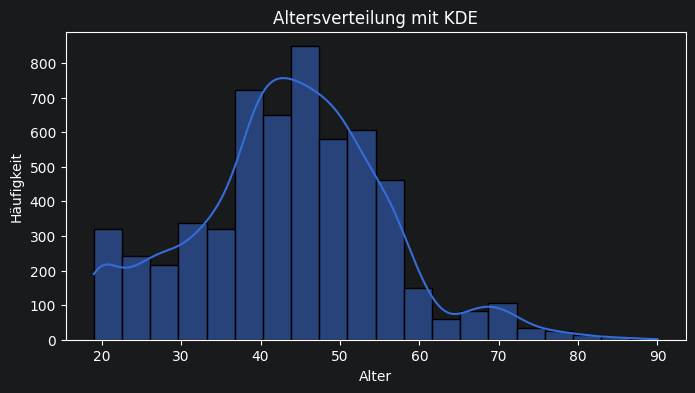

In [34]:
# Altersverteilung (statistische Kennzahlen)
print(users["age_years_cal"].describe())

# Histogramm + KDE
plt.figure(figsize=(8, 4))
sns.histplot(users["age_years_cal"], bins=20, kde=True)

plt.title("Altersverteilung mit KDE")
plt.xlabel("Alter")
plt.ylabel("Häufigkeit")
plt.show()


count    5782.000000
mean       38.620201
std         1.178423
min        35.000000
25%        38.000000
50%        39.000000
75%        39.000000
max        50.000000
Name: customer_age_months_calc, dtype: float64


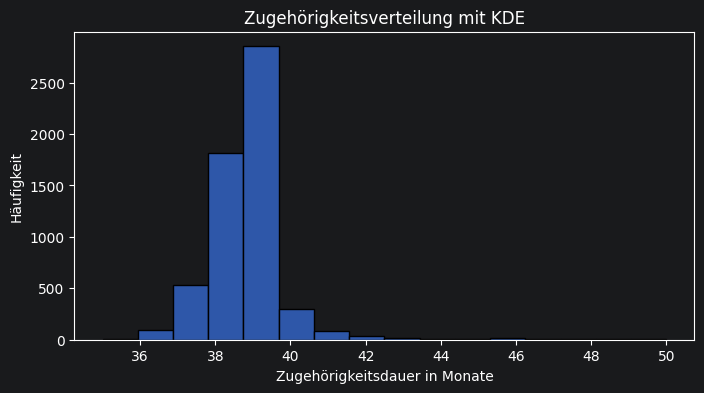

In [35]:
# KundeSeitSignUp in Monaten (statistische Kennzahlen)
print(users["customer_age_months_calc"].describe())

# Histogramm + KDE
plt.figure(figsize=(8, 4))
sns.histplot(users["customer_age_months_calc"], bins=16, kde=False)

plt.title("Zugehörigkeitsverteilung mit KDE")
plt.xlabel("Zugehörigkeitsdauer in Monate")
plt.ylabel("Häufigkeit")
plt.show()

#users["customer_age_months_calc"].value_counts().sort_index()

### User Gender

count     5782
unique       3
top          F
freq      5118
Name: gender, dtype: object


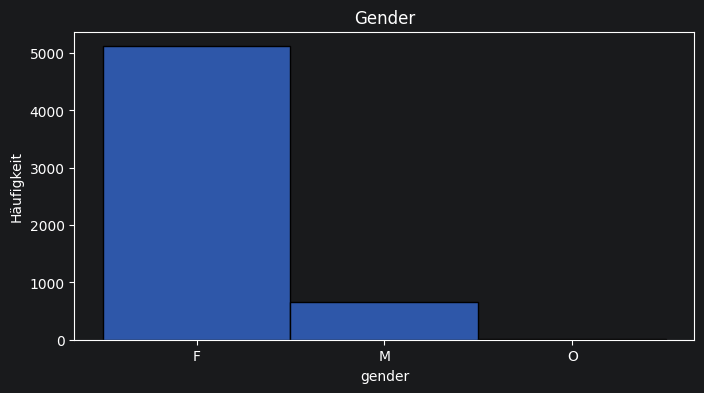

In [36]:
# Genderverteilung (statistische Kennzahlen)
print(users["gender"].describe())

# Histogramm
plt.figure(figsize=(8, 4))
sns.histplot(users["gender"], bins=20, kde=False)

plt.title("Gender")
plt.xlabel("gender")
plt.ylabel("Häufigkeit")
plt.show()


### User married

In [37]:
users["married"].value_counts(normalize=True)

married
False    0.557938
True     0.442062
Name: proportion, dtype: float64

### User has children

In [38]:
users["has_children"].value_counts(normalize=True)

has_children
False    0.673815
True     0.326185
Name: proportion, dtype: float64

### User Herkunft: Land, Stadt, Flughafen

In [39]:
print(users["home_country"].value_counts().head(10))
print(users["home_city"].value_counts().head(10))
print(users["home_airport"].value_counts().head(10))

home_country
usa       4808
canada     974
Name: count, dtype: int64
home_city
new york       657
los angeles    307
toronto        218
chicago        194
houston        179
montreal       160
san antonio    126
phoenix        114
dallas         110
san diego      109
Name: count, dtype: int64
home_airport
LGA    348
JFK    309
LAX    307
DAL    110
YYC    100
SFO     77
AUS     76
SJC     74
YOW     71
IND     71
Name: count, dtype: int64


### User Alter × Kinder

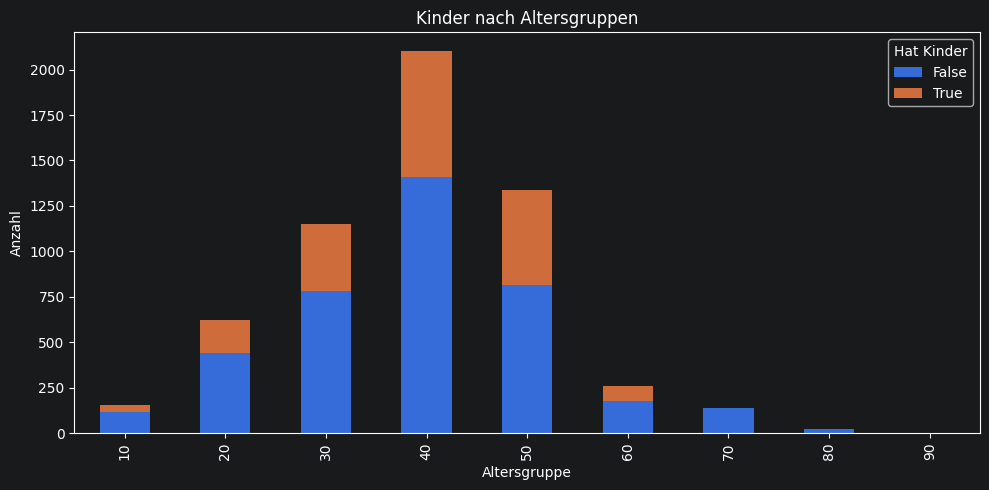

In [40]:
# Plot Häufigkeit Alter x Kinder

ct = pd.crosstab(users["age_years_cal"] // 10 * 10, users["has_children"])

# Plot
ct.plot(kind="bar", stacked=True, figsize=(10, 5))

plt.title("Kinder nach Altersgruppen")
plt.xlabel("Altersgruppe")
plt.ylabel("Anzahl")
plt.legend(title="Hat Kinder")
plt.tight_layout()
plt.show()

### hotels - TOP10

In [41]:
hotels.groupby("hotel_name").agg(
    bookings=("trip_id", "count"),
    avg_nights=("nights", "mean"),
    avg_price=("hotel_per_room_usd", "mean")
).sort_values("bookings", ascending=False).head(10)        #todo: bewusst nights noch nicht korrigiert, da systematisch in 2. Data_preparation gemacht wird

,bookings,avg_nights,avg_price
hotel_name,,,
Best Western - new york,115,3.330435,198.434783
Conrad - new york,115,3.765217,176.478261
Accor - new york,111,4.387387,197.477477
Aman Resorts - new york,108,3.916667,176.175926
Hilton - new york,107,3.261682,171.635514
Four Seasons - new york,107,4.691589,175.364486
Fairmont - new york,106,3.207547,209.754717
Wyndham - new york,106,4.018868,176.132075
Radisson - new york,102,3.647059,170.774510


### hotels - TOP10(Häufigkeit) NICHT stoniert

In [42]:
# Beliebteste Hotels (booking)

# Nicht stornierte Hotels
hotels_non_cancelled = hotels.merge(non_cancelled_trips, on="trip_id", how="inner")

# Häufigste Hotels
top_hotels_non_cancelled = hotels_non_cancelled["hotel_name"].value_counts().head(20)

top_hotels_non_cancelled

hotel_name
Conrad  - new york              113
Accor - new york                110
Best Western - new york         110
Hilton - new york               107
Aman Resorts - new york         105
Fairmont - new york             104
Four Seasons - new york         104
Wyndham - new york              104
Choice Hotels - new york        101
Shangri-La - new york            99
Crowne Plaza - new york          98
Extended Stay  - new york        97
NH Hotel  - new york             97
Radisson  - new york             97
Marriott  - new york             97
Banyan Tree  - new york          96
Rosewood - new york              93
Hyatt - new york                 90
InterContinental  - new york     90
Starwood  - new york             89
Name: count, dtype: int64

In [43]:
# Beliebteste Hotels (booking, nights, price)
top10_hotels_non_cancelled = (
    hotels_non_cancelled.groupby("hotel_name")
    .agg(
        bookings=("trip_id", "count"),
        avg_nights=("nights", "mean"),
        avg_price=("hotel_per_room_usd", "mean")
    )
    .sort_values("bookings", ascending=False)
    .head(10)
)

top10_hotels_non_cancelled

,bookings,avg_nights,avg_price
hotel_name,,,
Conrad - new york,113,3.734513,175.300885
Best Western - new york,110,3.072727,197.027273
Accor - new york,110,4.390909,198.736364
Hilton - new york,107,3.261682,171.635514
Aman Resorts - new york,105,4.000000,175.885714
Wyndham - new york,104,4.048077,174.038462
Fairmont - new york,104,3.019231,211.961538
Four Seasons - new york,104,4.673077,175.730769
Choice Hotels - new york,101,3.861386,191.782178


### hotels - Teuerste Hotels (Top 10 nach Preis) - non cancelled

In [44]:
top10_expensive_hotels_non_cancelled = (
    hotels_non_cancelled.groupby("hotel_name")
    .agg(
        avg_price=("hotel_per_room_usd", "mean"),
        bookings=("trip_id", "count"),
        avg_nights=("nights", "mean")
    )
    .sort_values("avg_price", ascending=False)
    .head(10)
)

top10_expensive_hotels_non_cancelled


,avg_price,bookings,avg_nights
hotel_name,,,
Extended Stay - dubai,687.000000,1,12.000000
Hyatt - venice,601.000000,1,15.000000
Fairmont - portland,508.500000,4,3.500000
Marriott - johor bahru,487.000000,1,16.000000
Wyndham - johor bahru,392.000000,1,11.000000
Aman Resorts - auckland,379.000000,1,16.000000
Fairmont - detroit,376.000000,6,3.500000
Shangri-La - bangkok,360.000000,1,7.000000
Starwood - seattle,340.555556,9,1.444444


### hotels - TOP nach dem längsten Aufenthalten

In [45]:
top10_longest_stays_non_cancelled = (
    hotels_non_cancelled.groupby("hotel_name")
    .agg(
        avg_nights=("nights", "mean"),
        bookings=("trip_id", "count"),
        avg_price=("hotel_per_room_usd", "mean")
    )
    .sort_values("avg_nights", ascending=False)
    .head(10)
)

top10_longest_stays_non_cancelled


,avg_nights,bookings,avg_price
hotel_name,,,
Radisson - macau,21.0,1,229.0
Conrad - phuket,20.0,1,124.0
Shangri-La - rome,18.0,1,132.0
Rosewood - warsaw,16.0,1,89.0
Marriott - johor bahru,16.0,1,487.0
Aman Resorts - auckland,16.0,1,379.0
Choice Hotels - singapore,16.0,1,299.0
Hyatt - venice,15.0,1,601.0
Conrad - guangzhou,15.0,1,96.0


### flights - Airlines TOP10

In [46]:
flights['trip_airline'].value_counts()

trip_airline
Delta Air Lines                   2013
American Airlines                 1997
United Airlines                   1776
Southwest Airlines                1061
Ryanair                            877
                                  ... 
Formosa Airlines                     1
Vietnam Airlines                     1
El Al Israel Airlines                1
Ukraine International Airlines       1
TransAsia Airways                    1
Name: count, Length: 174, dtype: int64

### flights - TOP10 Destinations NICHT stoniert

In [47]:
# Nicht stornierte Flüge
flights_non_cancelled = flights.merge(non_cancelled_trips, on="trip_id", how="inner")

# Häufigste Destinationen
top_destinations = flights_non_cancelled["destination"].value_counts().head(20)

# Häufigste Airlines
top_airlines = flights_non_cancelled["trip_airline"].value_counts().head(20)


### flights - Sitzplätze pro Flug

In [48]:
flights['seats'].describe()

count    13193.000000
mean         1.200106
std          0.552416
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: seats, dtype: float64

### flights - Preisschwankungen über Jahreszeiten

In [49]:
#season_price_stats

def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    if m in [3, 4, 5]:
        return "Spring"
    if m in [6, 7, 8]:
        return "Summer"
    return "Fall"

flights["season"] = flights["departure_time"].dt.month.apply(season_from_month)

season_price_stats = (
    flights.groupby("season")["base_fare_usd"]
    .agg(["mean", "std", "min", "max", "count"])
)

season_price_stats


,mean,std,min,max,count
season,,,,,
Fall,2612.003630,2876.980465,60.95,14466.33,135
Spring,457.607533,518.387467,2.41,12822.68,5894
Summer,440.016023,414.329236,4.10,6143.39,2376
Winter,492.406972,693.809549,2.87,14280.38,4788


### flights - Airlines – meistgenutzt in den letzten 6 Monaten

In [50]:
#top_airlines_6m

# Letzte 6 Monate
cutoff = flights["departure_time"].max() - pd.DateOffset(months=6)

flights_last6 = flights[flights["departure_time"] >= cutoff]

# Airlines zählen
top_airlines_6m = flights_last6["trip_airline"].value_counts().head(10)

top_airlines_6m


trip_airline
Delta Air Lines           21
American Airlines         18
United Airlines           16
Ryanair                   12
JetBlue Airways           10
Southwest Airlines         9
Alaska Airlines            6
AirTran Airways            6
Air Canada                 6
China Eastern Airlines     5
Name: count, dtype: int64

### flights vs sessions vs users - Distanz pro Flug in km

In [51]:
# flights → sessions → users
flights_users = (
    flights
    .merge(
        sessions[["trip_id", "user_id"]],
        on="trip_id",
        how="left"
    )
    .merge(
        users[["user_id", "home_airport_lat", "home_airport_lon"]],
        on="user_id",
        how="left"
    )
)

In [52]:
#from utils import haversine_distance
import numpy as np
def haversine_distance(lon1, lat1, lon2, lat2):
    """
    Calculate the great-circle distance between two points on Earth in km.
    Works with scalars or pandas Series / numpy arrays.
    """
    earth_radius_km = 6371.0

    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return earth_radius_km * c

# Use the function directly

flights_users["distance_km"] = haversine_distance(
    flights_users["home_airport_lon"],        # Origin lon
    flights_users["home_airport_lat"],        # Origin lat
    flights_users["destination_airport_lon"], # Destination lon
    flights_users["destination_airport_lat"], # Destination lat
)

In [53]:
flights_users["distance_km"].describe()

count    13727.000000
mean      2314.868543
std       1962.079585
min         17.673712
25%       1067.267081
50%       2051.823378
75%       3120.061792
max      17404.917859
Name: distance_km, dtype: float64

In [54]:
short_flights = flights_users[
    flights_users["distance_km"] < 200
][[
    "origin_airport",
    "destination_airport",
    "distance_km"
]].drop_duplicates().sort_values("distance_km")

<Axes: >

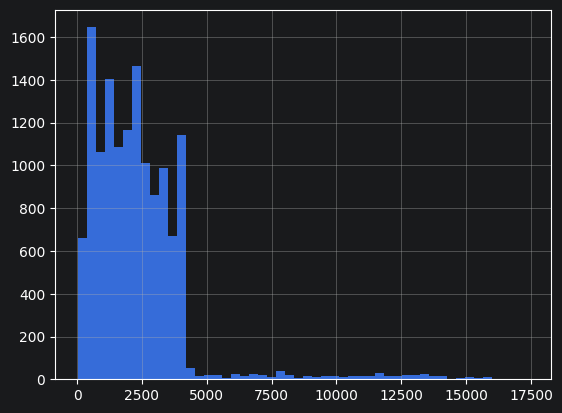

In [55]:
flights_users["distance_km"].hist(bins=50)

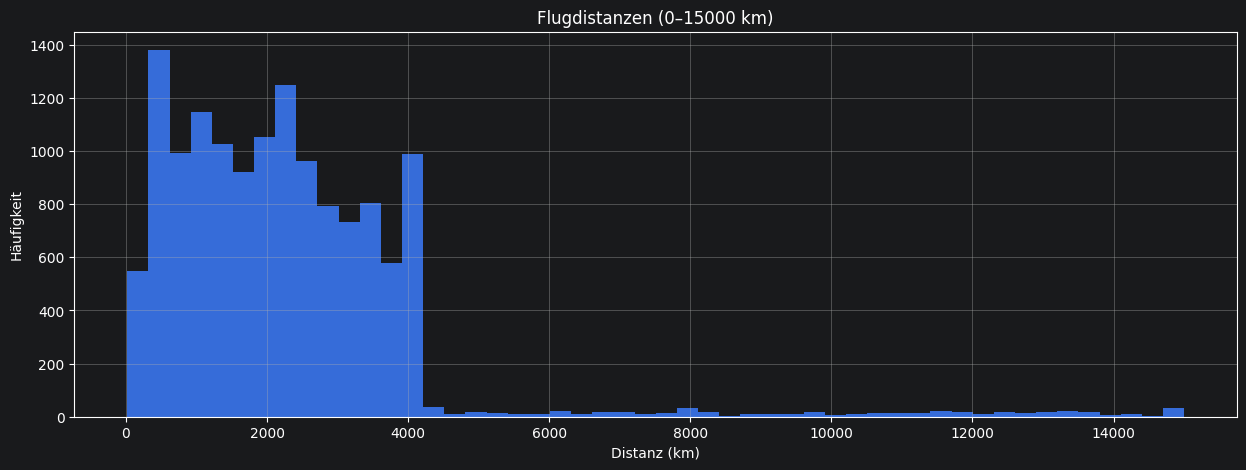

In [56]:
plt.figure(figsize=(15, 5))

flights_users["distance_km"].clip(upper=15000).hist(bins=50)

plt.title("Flugdistanzen (0–15000 km)")
plt.xlabel("Distanz (km)")
plt.ylabel("Häufigkeit")
plt.show()

In [57]:
print(short_flights.to_string())

      origin_airport destination_airport  distance_km
6633             OAK                 SFO    17.673712
5097             YND                 YOW    23.492222
1602             LGB                 LSQ    27.440552
10511            LGB                 LAX    27.440552
5671             EWR                 JFK    33.398343
296              EWR                 LGA    33.398343
9940             TCM                 BFI    45.517965
2779             FTW                 DAL    47.744509
2611             DAL                 FTW    47.744509
10553            DCA                 BWI    48.024378
11002            BWI                 DCA    48.024378
1307             SFO                 SJO    48.631691
1309             SFO                 SJC    48.631691
1648             SFO                 SJI    48.631691
956              SJC                 SFO    48.631691
2160             SNA                 LSQ    57.999896
11994            SNA                 LAX    57.999896
4971             UGN        

#### ✅ PLAUSIBEL (alles gut)

Typ: gleiche Metro / nahe Städte

🇺🇸 USA (klassische Multi-Airport Regionen)
OAK ↔ SFO (~18 km) ✅
EWR ↔ JFK / LGA (~33 km) ✅
DCA ↔ BWI (~48 km) ✅
LAX ↔ SAN (~175 km) ✅
AUS ↔ SAT (~95 km) ✅
DAL ↔ FTW (~48 km) ✅
ORD ↔ MKE (~108 km) ✅
DEN ↔ COS (~117 km) ✅
🇨🇦 Kanada (auch korrekt)
YND ↔ YOW (~23 km) ✅
YYJ ↔ YVR (~63 km) ✅
YUL ↔ YOW (~151 km) ✅
🇺🇸 kleine regionale Airports
CLE ↔ CMH (~180 km) ✅
IND ↔ LOU (~174 km) ✅
PHX ↔ DMA (~175 km) ✅

👉 Alles sehr plausibel

#### ❌ KLARE FEHLER (wichtig!)

Jetzt die echten Probleme 👇

🚨 1. LSQ (Chile!) taucht ständig auf

Beispiele:

LGB → LSQ ❌
SNA → LSQ ❌
RAL → LSQ ❌
SAN → LSQ ❌
BFL → LSQ ❌
NZY → LSQ ❌

👉 LSQ = Los Ángeles (Chile) 🇨🇱
👉 Daten behandeln es wie Los Angeles (USA) ❌

➡️ Massiver Mapping-Fehler

🚨 2. HLZ (Neuseeland!)
YYZ → HLZ ❌
YTZ → HLZ ❌
YZD → HLZ ❌
BUF → HLZ ❌

👉 HLZ = Hamilton (New Zealand) 🇳🇿
👉 völlig falsche Zuordnung

🚨 3. LGW (London!)
YZD → LGW (~157 km) ❌

👉 Kanada → London in 157 km?
➡️ unmöglich

🚨 4. Weitere falsche Mixes
YZD ↔ LGW ❌
BUF ↔ YKZ (~114 km) → prüfen (evtl. ok, aber grenzwertig)

In [58]:
suspect_distance = flights_users[
    (flights_users["distance_km"] < 30) |
    (flights_users["distance_km"] > 15000)
]

len(suspect_distance)

38

In [59]:
bad_airports = ["LSQ", "HLZ", "LGW"]

suspect_airports = flights_users[
    flights_users["destination_airport"].isin(bad_airports)
]

len(suspect_airports)

612

In [60]:
suspect_short = flights_users[
    (flights_users["distance_km"] < 100) &
    (flights_users["origin_airport"] != flights_users["destination_airport"])
]

len(suspect_short)

71

#### erkenntnisse distance vs airport
Total: 13,712 Flüge
bad_airports: 612 → ~4.5% ❗ (hoch)
suspect_short: 71 → ~0.5%
suspect_distance: 38 → ~0.3%

❗ Der Hauptfehler sind NICHT Ausreißer, sondern falsche Airport-Zuordnungen

🧠 Interpretation
4.5% ist viel → das ist kein „Rauschen“
das ist ein systematischer Fehler im Datensatz
👉 (z. B. LSQ, HLZ, LGW)

### flights vs sessions vs users - Hemisphärenwechsel, Aquatorreisen, Pole Reisen

#### Hemisphärenwechsel

In [61]:
flights_users["hemisphere_change"] = (
    (flights_users["home_airport_lat"] * flights_users["destination_airport_lat"]) < 0
)

##### Erkenntnis: nur 20 Fälle => nicht relevantes Verhalten

#### Clima direction - wärmer/kälter

In [62]:
flights_users["climate_direction"] = np.where(
    abs(flights_users["destination_airport_lat"]) < abs(flights_users["home_airport_lat"]),
    "wärmer",
    "kälter"
)

##### Erkenntnis: zu grob, nicht weiter verfolgen

#### Klimareiser-Features

##### Nord-Süd-Distanz in km

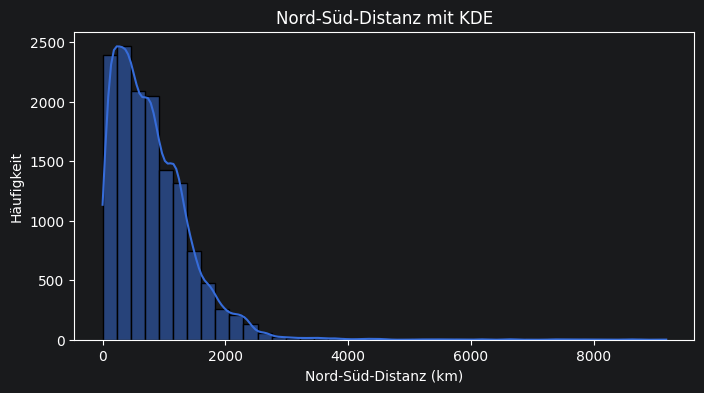

In [63]:
# Nord-Süd-Distanz in km
flights_users["lat_diff_km"] = (
    (flights_users["destination_airport_lat"] - flights_users["home_airport_lat"]).abs()
    * 111
)
# Histogramm + KDE
plt.figure(figsize=(8, 4))
sns.histplot(flights_users["lat_diff_km"], bins=40, kde=True)

plt.title("Nord-Süd-Distanz mit KDE")
plt.xlabel("Nord-Süd-Distanz (km)")
plt.ylabel("Häufigkeit")
plt.show()

##### Bewegungs-Kategorie Nord-Süd-Distanz (lokal, regional, global)

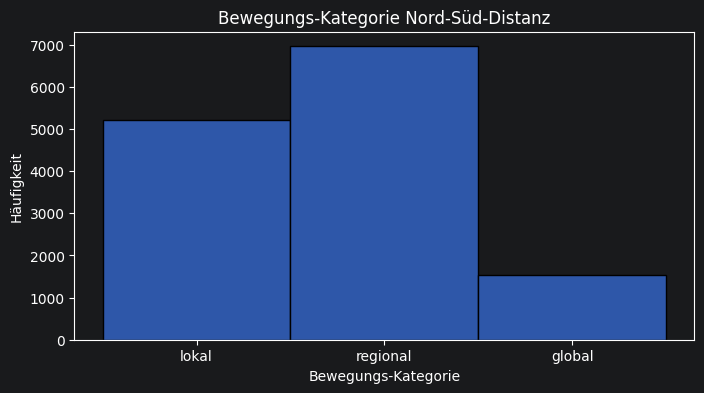

In [64]:
# Bewegungs-Kategorie (Feinschliff)
flights_users["distance_category"] = pd.cut(
    flights_users["lat_diff_km"],
    bins=[0, 500, 1500, np.inf],
    labels=["lokal", "regional", "global"]
)
# Histogramm + KDE
plt.figure(figsize=(8, 4))
sns.histplot(flights_users["distance_category"], bins=40, kde=False)

plt.title("Bewegungs-Kategorie Nord-Süd-Distanz")
plt.xlabel("Bewegungs-Kategorie")
plt.ylabel("Häufigkeit")
plt.show()

##### Tropen - und Subtropengürtel

In [65]:
# Tropen - und Subtropengürtel
flights_users["to_tropics"] = (
    abs(flights_users["destination_airport_lat"]) < 23.5+8
)

###### Erkenntnis: ca. 1500 Fälle sub and tropics

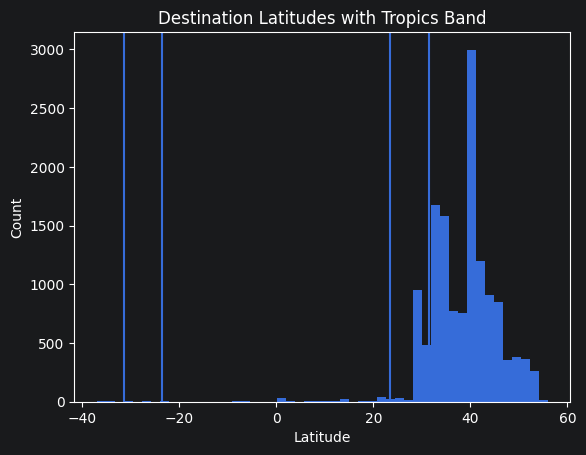

In [66]:
# Histogramm der Latitudes
plt.figure()
plt.hist(flights_users["destination_airport_lat"], bins=50)

# Linien für Grenzen
plt.axvline(23.5)
plt.axvline(-23.5)
plt.axvline(31.5)
plt.axvline(-31.5)

plt.title("Destination Latitudes with Tropics Band")
plt.xlabel("Latitude")
plt.ylabel("Count")

plt.show()

###### Erkenntnis - Tropengürtel: weniger als 200 Fälle (nicht relevant) vielleicht zusammen mit subtropen

##### Weltkarte hotspots Reiseziele

In [67]:
#Folium (interaktive Weltkarte)
import folium
from folium.plugins import HeatMap

# Basis Weltkarte
m = folium.Map(location=[20, 0], zoom_start=2)

# Daten vorbereiten
heat_data = flights_users[
    ["destination_airport_lat", "destination_airport_lon"]
].dropna().values.tolist()

# Heatmap hinzufügen
HeatMap(heat_data).add_to(m)

# speichern
# m.save("heatmap.html")
m.save(r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\05_visualizations\heatmap.html")

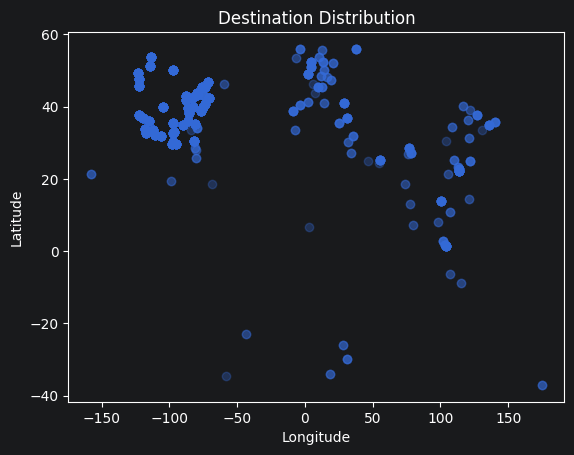

In [68]:
#Scatter Map
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    flights_users["destination_airport_lon"],
    flights_users["destination_airport_lat"],
    alpha=0.3
)

plt.title("Destination Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [69]:
# heatmap_weighted.html
df = flights_users.groupby(
    ["destination_airport_lat", "destination_airport_lon"]
).size().reset_index(name="count")

m = folium.Map(location=[20, 0], zoom_start=2)

heat_data = df[
    ["destination_airport_lat", "destination_airport_lon", "count"]
].values.tolist()

HeatMap(heat_data).add_to(m)

# m.save("heatmap_weighted.html")
m.save(r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\05_visualizations\heatmap_weighted.html")

##### Klimarichtung

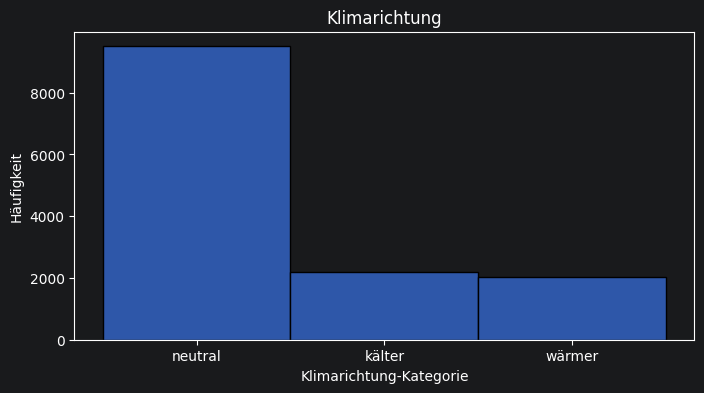

In [70]:
# Klimarichtung
flights_users["climate_direction"] = np.where(
    flights_users["lat_diff_km"] < 1000,
    "neutral",
    np.where(
        abs(flights_users["destination_airport_lat"]) < abs(flights_users["home_airport_lat"]),
        "wärmer",
        "kälter"
    )
)
# Histogramm + KDE
plt.figure(figsize=(8, 4))
sns.histplot(flights_users["climate_direction"], bins=40, kde=False)

plt.title("Klimarichtung")
plt.xlabel("Klimarichtung-Kategorie")
plt.ylabel("Häufigkeit")
plt.show()

##### Klimasegment (kombiniert)

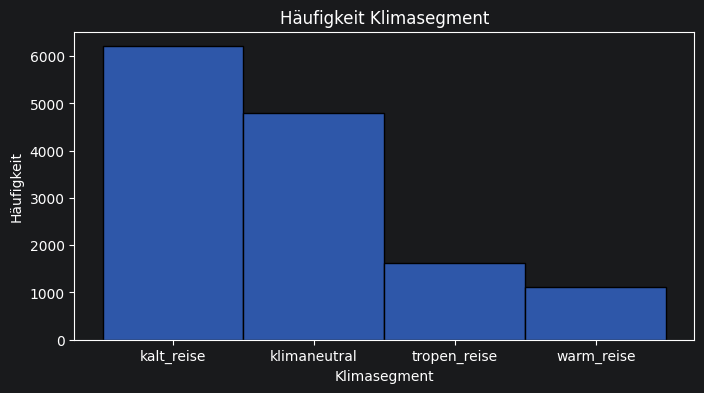

In [71]:
# Klimasegment (kombiniert)
def climate_segment(row):
    if row["to_tropics"]:
        return "tropen_reise"
    elif row["distance_category"] == "lokal":
        return "klimaneutral"
    elif row["climate_direction"] == "wärmer":
        return "warm_reise"
    else:
        return "kalt_reise"

flights_users["climate_segment"] = flights_users.apply(climate_segment, axis=1)

# Histogramm + KDE
plt.figure(figsize=(8, 4))
sns.histplot(flights_users["climate_segment"], bins=40, kde=False)

plt.title("Häufigkeit Klimasegment")
plt.xlabel("Klimasegment")
plt.ylabel("Häufigkeit")
plt.show()

##### Winter Escaper

In [72]:
# Winter Escaper (stärkstes Feature)
flights_users["winter_escape"] = (                      #PotentialUserFeaturerColumn
    (flights_users["season"] == "Winter") &
    #(flights_users["climate_direction"] == "wärmer")
    (flights_users["climate_segment"] == "tropen_reise")            #
)
flights_users.columns

Index(['trip_id', 'origin_airport', 'destination', 'destination_airport',
       'seats', 'return_flight_booked', 'departure_time', 'return_time',
       'checked_bags', 'trip_airline', 'destination_airport_lat',
       'destination_airport_lon', 'base_fare_usd', 'is_one_way',
       'flight_duration_calc', 'season', 'user_id', 'home_airport_lat',
       'home_airport_lon', 'distance_km', 'hemisphere_change',
       'climate_direction', 'lat_diff_km', 'distance_category', 'to_tropics',
       'climate_segment', 'winter_escape'],
      dtype='str')

In [73]:
# Winter Escape Verteilung (Destination + Airline), Tabelle

# Filter
df_winter = flights_users[flights_users["winter_escape"] == True]

# Aggregation
table = (
    df_winter
    .groupby(["destination", "trip_airline"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(table.head(20))

     destination        trip_airline  count
57       houston     United Airlines     66
55       houston  Southwest Airlines     45
86   san antonio            Conviasa     35
63  jacksonville   American Airlines     28
10        austin  Southwest Airlines     24
87   san antonio     Delta Air Lines     24
44       houston   American Airlines     23
91   san antonio     United Airlines     22
85   san antonio   American Airlines     22
64  jacksonville     Delta Air Lines     20
68  jacksonville     United Airlines     19
89   san antonio             Ryanair     18
40       houston     AirTran Airways     18
46       houston     Delta Air Lines     16
54       houston             Ryanair     15
1         austin     AirTran Airways     14
66  jacksonville             Ryanair     12
11        austin     United Airlines     10
6         austin     Delta Air Lines     10
4         austin   American Airlines     10


In [74]:
top_dest = (
    df_winter
    .groupby("destination")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(top_dest.head(20))

       destination  count
11         houston    210
24     san antonio    141
0           austin     88
13    jacksonville     86
27       singapore     15
4            dubai     10
9        hong kong      9
1          bangkok      8
3            delhi      5
16     johor bahru      4
2            cairo      3
19           macau      3
12        hurghada      3
26        shenzhen      3
23  rio de janeiro      2
7           guilin      2
5           durban      2
8            hanoi      2
6        guangzhou      2
15         jakarta      2


In [75]:
import folium
from folium.plugins import HeatMap

# nur Winter Escape
df_winter = flights_users[flights_users["winter_escape"] == True]

# Map
m = folium.Map(location=[20, 0], zoom_start=2)

# Daten
heat_data = df_winter[
    ["destination_airport_lat", "destination_airport_lon"]
].dropna().values.tolist()

# Heatmap
HeatMap(heat_data).add_to(m)

# speichern
# m.save("winter_escape_heatmap.html")
m.save(r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\05_visualizations\winter_escape_heatmap.html")

###### Erkenntnis - Winter Escaper: keine!

### users vs sessions - Gender × flight_booked

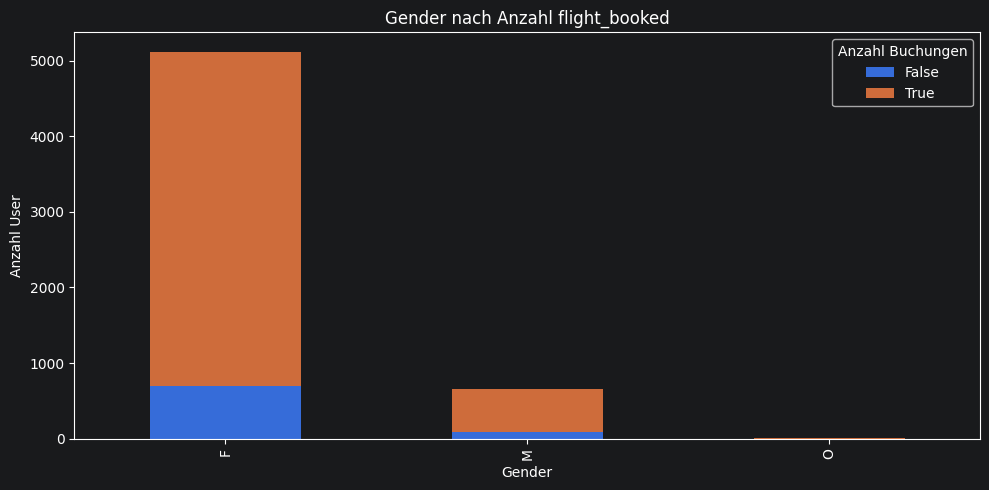

In [76]:
# Plot Häufigkeit Gender x Flight_booked

# 1. Aggregation auf User-Level
sessions_user = (sessions.groupby("user_id")["flight_booked"].max().reset_index())

df = users.merge(sessions_user, on="user_id", how="left")

# fehlende Werte (User ohne Buchung) = 0
df["flight_booked"] = df["flight_booked"].fillna(0)

# 3. Crosstab (hier sinnvoll: gruppieren!)
ct = pd.crosstab(df["gender"], df["flight_booked"])

# Plot
ct.plot(kind="bar", stacked=True, figsize=(10, 5))

plt.title("Gender nach Anzahl flight_booked")
plt.xlabel("Gender")
plt.ylabel("Anzahl User")
plt.legend(title="Anzahl Buchungen")
plt.tight_layout()
plt.show()

### flights vs sessions - StornoAnzahl per Destination

In [77]:
cancelled_flights = flights.merge(cancelled_trips, on="trip_id", how="inner")
cancelled_flights["destination"].value_counts().head(10)

destination
new york        47
los angeles     29
toronto         25
chicago         17
san antonio     15
calgary         15
phoenix         15
houston         13
philadelphia    13
dallas          12
Name: count, dtype: int64

### hotels vs sessions - StornoAnzahl per Hotel

In [78]:
cancelled_hotels = hotels.merge(cancelled_trips, on="trip_id", how="inner")
cancelled_hotels["hotel_name"].value_counts().head(10)

hotel_name
InterContinental  - new york    5
Radisson  - new york            5
Marriott  - toronto             5
Best Western - new york         5
Marriott  - los angeles         4
Accor - los angeles             3
Marriott  - nashville           3
Starwood  - new york            3
Aman Resorts - new york         3
Radisson  - san antonio         3
Name: count, dtype: int64

---

### 📊 RESUME – Explorative Datenanalyse (EDA) – Zusammenfassung

#### 1. Nutzerprofil

##### **Alter**
```text
count    5782
mean       43.6
std        12.0
min        19
25%        37
50%        44
75%        51
max        90
```
**Insight:** Schwerpunkt im Bereich 30–55 Jahre.

---

##### **Geschlecht**
```text
F: 5118
M: ~600
Other: wenige
```
**Insight:** Stark weiblich dominierte Nutzerbasis.

---

##### **Herkunft**

**Länder**
```text
USA:    4808
Canada:  974
```

**Städte (Top 10)**
```text
New York       657
Los Angeles    307
Toronto        218
Chicago        194
Houston        179
Montreal       160
San Antonio    126
Phoenix        114
Dallas         110
San Diego      109
```

**Heimatflughäfen (Top 10)**
```text
LGA 348
JFK 309
LAX 307
DAL 110
YYC 100
SFO  77
AUS  76
SJC  74
YOW  71
IND  71
```

**Insight:** Klare Dominanz nordamerikanischer Metropolregionen.

---

##### **Familienstatus**
```text
unmarried: 55.8%
married:   44.2%
```
**Insight:** Ausgewogene Verteilung.

---

#### 2. Nutzerverhalten

##### **Page Clicks**
```text
count: 47436
mean:  17.6
std:   21.5
min:   1
25%:   6
50%:   13
75%:   22
max:   566
```
**Insight:** Mehrheit mit kurzen Sessions, wenige Heavy‑User.

---

##### **Buchungsraten pro Session**
```text
Flug:  29.0%
Hotel: 30.3%
```
**Insight:** Hohe Conversion‑Rate.

---

##### **Buchungen pro Nutzer**
```text
mean flights: 2.38
mean hotels:  2.48
mean total:   4.87
max total:    18
```
**Insight:** Hoher Anteil an Mehrfachbuchern.

---

##### **Conversion nach Klick‑Bins**
```text
0–5 clicks:   0.000
6–10 clicks:  0.023
11–20 clicks: 0.360
21–50 clicks: 0.638
50+ clicks:   0.676
```
**Insight:** Starker Anstieg der Conversion ab ca. 20 Klicks.

---

##### **Stornierungen**
```text
mean cancellations: 0.102
max cancellations: 2
Users mit ≥1 Storno: 574
```
**Insight:** Stornos selten, aber relevant.

---

#### 3. Reiseverhalten
*Aggregationen zu Destinationen, Airlines und Hotels folgen in Woche 2.*

---

#### 4. Datenqualität

##### **Hotel‑Nights korrigiert**
- Fehlerhafte Zeitstempel korrigiert
- Neue Variablen: `bezahlte_nights_cal`, `nutzungs_typ`, `nights_final`

##### **Strukturelle NaNs modelliert**
- `has_trip`
- `has_flight_discount`
- `has_hotel_discount`
- `is_one_way`

**Insight:** Datensatz ist konsistent und ML‑ready.

---

#### 5. Erste Hypothesen

- Page Clicks als starker Prädiktor für Buchung
- Einfluss von Alter und Familienstatus auf Reisedauer
- Einfluss des Heimatflughafens auf Destinationen
- Höhere Storno‑Wahrscheinlichkeit bei Nutzern mit Stornohistorie
- Stabilere Conversion bei Power‑Usern

---

Wenn gewünscht, kann daraus auch eine kompakte Präsentationsversion oder ein visuelles EDA‑Dashboard entwickelt werden.

# Feature Engineering und Datensplits.

## hotels -  Datensatz Qualität verbessern

### nights <= 0
Nicht einfach löschen. Die Spalte nights ist zentral für:
* Aufenthaltsdauer
* Hotelverhalten
* Preisberechnung
* spätere Segmentierung (z. B. Vielreisende vs. Kurztrips)

In [79]:
# hotels filtern 'nights' <= 0
hotels[hotels["nights"] <= 0]

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,stay_duration_calc
36,190866-39f7fdf3561541bd990b5bca9c8c18d1,Fairmont - toronto,0,1,2023-03-28 15:57:01.260,2023-03-29 11:00:00,137,0 days 19:02:58.740000
41,204943-104f0428d48b41548c8c62045d2b3af7,Four Seasons - new york,0,1,2023-03-28 15:40:43.050,2023-03-29 11:00:00,53,0 days 19:19:16.950000
52,206011-1eee865398c846379976aa1a8f76608f,Hilton - san jose,0,1,2023-05-09 12:58:05.925,2023-05-10 11:00:00,83,0 days 22:01:54.075000
61,224996-c83b5f33943b4cbf8ec93049c6fb6166,Banyan Tree - new york,0,1,2023-05-20 18:12:04.095,2023-05-21 11:00:00,231,0 days 16:47:55.905000
72,229330-d4a91967362b4441913d13f5bc8156a3,Extended Stay - los angeles,0,2,2023-01-29 11:40:26.985,2023-01-29 11:00:00,164,-1 days +23:19:33.015000
...,...,...,...,...,...,...,...,...
13747,767426-0ee782f33778461893e25fb02c64b429,NH Hotel - baltimore,0,1,2023-07-17 14:58:26.220,2023-07-18 11:00:00,146,0 days 20:01:33.780000
13750,768291-6571708d6a0445b683464f6cabecda0a,Four Seasons - houston,-1,1,2023-06-18 09:29:35.610,2023-06-17 11:00:00,112,-1 days +01:30:24.390000
13759,785107-cef86dc91537459191af26b455631767,Choice Hotels - calgary,0,1,2023-07-29 16:06:07.200,2023-07-30 11:00:00,430,0 days 18:53:52.800000
13761,785186-0a75d75bdb334656aa3918c33cd57e31,InterContinental - philadelphia,0,1,2023-06-11 19:00:18.720,2023-06-12 11:00:00,107,0 days 15:59:41.280000


In [80]:
# Ungültige Fälle isolieren

invalid = hotels[hotels["nights"] <= 0].copy()
print("Anzahl ungültiger Fälle:", len(invalid))
invalid#.head()

Anzahl ungültiger Fälle: 1259


,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,stay_duration_calc
36,190866-39f7fdf3561541bd990b5bca9c8c18d1,Fairmont - toronto,0,1,2023-03-28 15:57:01.260,2023-03-29 11:00:00,137,0 days 19:02:58.740000
41,204943-104f0428d48b41548c8c62045d2b3af7,Four Seasons - new york,0,1,2023-03-28 15:40:43.050,2023-03-29 11:00:00,53,0 days 19:19:16.950000
52,206011-1eee865398c846379976aa1a8f76608f,Hilton - san jose,0,1,2023-05-09 12:58:05.925,2023-05-10 11:00:00,83,0 days 22:01:54.075000
61,224996-c83b5f33943b4cbf8ec93049c6fb6166,Banyan Tree - new york,0,1,2023-05-20 18:12:04.095,2023-05-21 11:00:00,231,0 days 16:47:55.905000
72,229330-d4a91967362b4441913d13f5bc8156a3,Extended Stay - los angeles,0,2,2023-01-29 11:40:26.985,2023-01-29 11:00:00,164,-1 days +23:19:33.015000
...,...,...,...,...,...,...,...,...
13747,767426-0ee782f33778461893e25fb02c64b429,NH Hotel - baltimore,0,1,2023-07-17 14:58:26.220,2023-07-18 11:00:00,146,0 days 20:01:33.780000
13750,768291-6571708d6a0445b683464f6cabecda0a,Four Seasons - houston,-1,1,2023-06-18 09:29:35.610,2023-06-17 11:00:00,112,-1 days +01:30:24.390000
13759,785107-cef86dc91537459191af26b455631767,Choice Hotels - calgary,0,1,2023-07-29 16:06:07.200,2023-07-30 11:00:00,430,0 days 18:53:52.800000
13761,785186-0a75d75bdb334656aa3918c33cd57e31,InterContinental - philadelphia,0,1,2023-06-11 19:00:18.720,2023-06-12 11:00:00,107,0 days 15:59:41.280000


In [81]:
# Check-out Uhrzeit extrahieren & Häufigkeit checken

# Stunde extrahieren
invalid["checkout_hour"] = invalid["check_out_time"].dt.hour
invalid["checkout_minute"] = invalid["check_out_time"].dt.minute

# Häufigkeit der Check-out-Stunden
print("Check-out Stundenverteilung bei ungültigen nights:")
print(invalid["checkout_hour"].value_counts().sort_index())

# Häufigkeit der Minuten (wichtig für Muster wie 11:00)
print("\nCheck-out Minutenverteilung bei ungültigen nights:")
print(invalid["checkout_minute"].value_counts().sort_index())

Check-out Stundenverteilung bei ungültigen nights:
checkout_hour
11    1259
Name: count, dtype: int64

Check-out Minutenverteilung bei ungültigen nights:
checkout_minute
0    1259
Name: count, dtype: int64


In [82]:
# Berechnung der tatsächlichen Aufenthaltsdauer

hotels["stay_calc"] = (hotels["check_out_time"] - hotels["check_in_time"]).dt.days

#Ungültige Fälle neu isolieren (damit stay_calc enthalten ist)
invalid = hotels[hotels["nights"] <= 0].copy()

# Vergleich nights vs. berechnete Dauer
invalid_compare = invalid[["nights", "stay_calc", "check_in_time", "check_out_time"]]

print("\nVergleich nights vs. berechnete Aufenthaltsdauer:")
invalid_compare.sample(10)



Vergleich nights vs. berechnete Aufenthaltsdauer:


,nights,stay_calc,check_in_time,check_out_time
9113,0,0,2023-02-05 15:26:55.140,2023-02-06 11:00:00
5695,0,0,2023-03-12 09:52:24.600,2023-03-12 11:00:00
1021,0,0,2023-04-12 18:04:16.590,2023-04-13 11:00:00
2067,0,0,2023-04-05 12:07:19.110,2023-04-06 11:00:00
824,0,0,2023-03-17 13:31:34.545,2023-03-18 11:00:00
9624,0,0,2023-03-22 18:11:22.965,2023-03-23 11:00:00
8095,0,0,2023-04-23 17:19:17.715,2023-04-24 11:00:00
12974,0,0,2023-03-14 22:30:32.490,2023-03-15 11:00:00
4601,0,0,2023-02-06 15:34:03.045,2023-02-07 11:00:00
7504,0,0,2023-07-17 19:12:19.890,2023-07-18 11:00:00


In [83]:
# Fälle mit negativer berechneter Dauer prüfen

negative_stay = invalid[invalid["stay_calc"] < 0]

print("Fälle mit negativer berechneter Aufenthaltsdauer:")
negative_stay[["nights", "stay_calc", "check_in_time", "check_out_time"]]#.head(10)

Fälle mit negativer berechneter Aufenthaltsdauer:


,nights,stay_calc,check_in_time,check_out_time
72,0,-1,2023-01-29 11:40:26.985,2023-01-29 11:00:00
86,0,-1,2023-01-31 11:52:12.585,2023-01-31 11:00:00
100,0,-1,2023-07-16 11:49:54.570,2023-07-16 11:00:00
128,0,-1,2023-01-25 11:20:12.300,2023-01-25 11:00:00
170,0,-1,2023-04-30 11:33:40.590,2023-04-30 11:00:00
...,...,...,...,...
13610,0,-1,2023-04-20 11:26:07.845,2023-04-20 11:00:00
13611,-1,-1,2023-05-20 13:46:41.160,2023-05-20 11:00:00
13711,0,-1,2023-04-17 11:36:56.430,2023-04-17 11:00:00
13722,0,-1,2023-05-24 11:51:43.200,2023-05-24 11:00:00


#### Konzept - Beschreibung: Neuberechnung `nights`


##### Ziel
- Konsistente Berechnung der Nächte unabhängig von Uhrzeiten
- Korrektur von `nights <= 0` und negativen `stay_calc`


##### Neue Logik: `bezahlte_nights_cal` (tagebasiert)

- `check_in_date = date(check_in_time)`
- `check_out_date = date(check_out_time)`
- `diff = (check_out_date - check_in_date).days`

**Regel:**
- `diff <= 0` → `bezahlte_nights_cal = 1`
- `diff > 0` → `bezahlte_nights_cal = diff`

##### Umgang mit fehlerhaften `nights`

- Fälle mit `nights ∈ {0, -1, -2}` sind inkonsistent
- Ursache: systematische Verzerrung durch `check_out_time = 11:00`

**Lösung:**
- Originalwerte ignorieren bei `nights <= 0`
- Ersetzen durch `bezahlte_nights_cal`

##### Klassifikation `nutzungs_typ`

- `stunden_nutzung`:
  - gleiches Datum (`diff = 0`)
  - Dauer < 8h
- `normale_nacht`:
  - `bezahlte_nights_cal >= 1`
  - plausible Aufenthaltsdauer (ca. 8–36h)

##### Umgang mit `stay_calc < 0`

- `stay_calc` ignorieren
- Keine Imputation notwendig
- Optional:
  - Ausschluss aus Analysen
  - oder Median-Wert setzen (~2 Nächte)

##### Validierung

- Verteilung prüfen:
  - Anzahl `nights = 0, -1, -2`
- Kreuztabelle:
  - Original `nights` vs. `bezahlte_nights_cal`
- Ziel:
  - Identifikation und Korrektur fehlerhafter Fälle

##### Finale Variable: `nights_final`

- Wenn `nights > 0` und plausibel (±1):
  - `nights_final = nights`
- Wenn `nights <= 0`:
  - `nights_final = bezahlte_nights_cal`
- Optional:
  - Flag bei Ausreißern (`nights_flag = 'outlier'`)

##### Fazit

- Uhrzeiten sind systemisch verzerrt → ignorieren
- Tagesdifferenz ist maßgeblich
- Negative und 0-Werte werden konsistent korrigiert
- Sonderfälle bleiben über Klassifikation erhalten

#### Konzept - Umsetzung: bezahlte_nights_cal (korrekt berechnete Nächte (tagebasiert))

In [84]:
# Neue Spalte: bezahlte_nights_cal (tagebasiert)

# Datum ohne Uhrzeit, aber weiterhin datetime64
hotels["check_in_date"] = hotels["check_in_time"].dt.normalize()
hotels["check_out_date"] = hotels["check_out_time"].dt.normalize()

# Tagesdifferenz berechnen (jetzt funktioniert .dt.days)
hotels["diff_days"] = (hotels["check_out_date"] - hotels["check_in_date"]).dt.days

# bezahlte Nächte: mindestens 1
hotels["bezahlte_nights_cal"] = hotels["diff_days"].apply(lambda x: max(1, x))

In [85]:
# Nutzungs-Typ bestimmen

# Aufenthaltsdauer in Stunden
hotels["stay_hours"] = (hotels["check_out_time"] - hotels["check_in_time"]).dt.total_seconds() / 3600

def classify_usage(row):
    same_day = row["check_in_date"] == row["check_out_date"]
    short_stay = row["stay_hours"] < 8
    if same_day and short_stay:
        return "stunden_nutzer"
    else:
        return "normale_nacht"

hotels["nutzungs_typ"] = hotels.apply(classify_usage, axis=1)           #PotentialUserFeaturerColumn

In [86]:
# Finale Nächtezahl bestimmen

def final_nights(row):
    if row["nights"] > 0:
        return row["nights"]
    else:
        return row["bezahlte_nights_cal"]

hotels["nights_final"] = hotels.apply(final_nights, axis=1)             #PotentialUserFeaturerColumn

#### Konzept - Validierung: mit Tabellen überprüfen, ob die Bereinigung Night korrekt funktioniert hat.

In [87]:
# Kreuztabelle: nights vs bezahlte_nights_cal
pd.crosstab(hotels["nights"], hotels["bezahlte_nights_cal"])

bezahlte_nights_cal,1,2,3,4,5,6,7,8,9,10,...,29,30,31,32,33,34,35,40,42,43
nights,,,,,,,,,,,,,,,,,,,,,
-2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-1,100,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,1158,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,857,2161,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,878,1815,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,651,1231,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,532,777,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,408,448,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,352,290,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [88]:
# Kreuztabelle: nights vs nights_final
pd.crosstab(hotels["nights"], hotels["nights_final"])

nights_final,1,2,3,4,5,6,7,8,9,10,...,29,30,31,32,33,34,35,40,42,43
nights,,,,,,,,,,,,,,,,,,,,,
-2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-1,100,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,1158,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3018,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2693,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1882,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1309,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,856,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,642,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [89]:
# Häuifkeit: nutzungs_typ
hotels["nutzungs_typ"].value_counts()

nutzungs_typ
normale_nacht     13384
stunden_nutzer      388
Name: count, dtype: int64

In [90]:
# Häuifkeit: "nights_final" < 1
hotels[hotels["nights_final"] < 1]

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,stay_duration_calc,stay_calc,check_in_date,check_out_date,diff_days,bezahlte_nights_cal,stay_hours,nutzungs_typ,nights_final


#### ENDE NIGHTS KORREKTUR

Zusammenfassung
Die Analyse zeigt, dass die ursprüngliche Spalte nights in vielen Fällen fehlerhaft ist.
* Die systematische Verwendung von 11:00 Uhr als Check‑out‑Zeit führt zu falschen Differenzen.
* Durch die tagebasierte Berechnung der Nächte und die Einführung der Spalten bezahlte_nights_cal, nutzungs_typ und nights_final entsteht eine robuste, realistische und konsistente Grundlage für alle weiteren Analysen.


## sessions - Datensatz Qualität verbessern

### datum format setzen     todo: schon in EDA gemacht

In [91]:
# Datumsfelder
sessions["session_start"] = pd.to_datetime(sessions["session_start"])
sessions["session_end"] = pd.to_datetime(sessions["session_end"])

## flights - Datensatz Qualität verbessern

### datum format setzen todo: schon in EDA gemacht

In [92]:
flights["departure_time"] = pd.to_datetime(flights["departure_time"])

## FEA: Dictionary erzeugen

In [93]:
feature_tables = {}

## FEA: cancelled und non-cancelled trips isolieren

In [94]:
# Stornierte Trips
cancelled_trips = (
    sessions[sessions["cancellation"] == True][["trip_id"]]
    .dropna()
    .drop_duplicates()
)

In [95]:
# Nicht stornierte Trips
non_cancelled_trips = (
    sessions[["trip_id"]]
    .dropna()
    .drop_duplicates()
    .merge(cancelled_trips, on="trip_id", how="left", indicator=True)
)
non_cancelled_trips = non_cancelled_trips[non_cancelled_trips["_merge"] == "left_only"][["trip_id"]]

## FEA: non-cancelled flights_users isolieren

In [96]:
# flights → sessions → users
# Achtung, darf nicht erneut erzeugt werden, da schon in Teil 2 und FEA spalten erzeugt wurden
#flights_users = (
#    flights
#    .merge(
#        sessions[["trip_id", "user_id"]],
#        on="trip_id",
#        how="left"
#    )
#    .merge(
#        users[["user_id", "home_airport_lat", "home_airport_lon"]],
#        on="user_id",
#        how="left"
#    )
#)

In [97]:
# flights_users nur nicht-storniert
flights_users_nc = flights_users.merge(non_cancelled_trips, on="trip_id", how="inner")

## FEA: non-cancelled hotels_users isolieren

In [98]:
# hotels → sessions → users
hotels_users = (
    hotels
    .merge(
        sessions[["trip_id", "user_id"]],
        on="trip_id",
        how="left"
    )
    .merge(
        users[["user_id"]],
        on="user_id",
        how="left"
    )
)

In [99]:
# hotels_users nur nicht-storniert
hotels_users_nc = hotels_users.merge(non_cancelled_trips, on="trip_id", how="inner")

## FEA's erzeugen

In [100]:
# Session-Dauer
sessions["session_time_sec"] = (sessions["session_end"] - sessions["session_start"]).dt.total_seconds()    # todo: klären ob es nochmal gebracht wird


### FEA: Engagement (sessions and clicks)

In [101]:
engagement = sessions.groupby("user_id").agg(
    sessions_ttl=("session_id", "count"),             #UserFeature
    clicks_avg=("page_clicks", "mean")                  #UserFeature
).reset_index()

feature_tables["engagement"] = engagement

### FEA: Conversion Rate

In [102]:
sessions["any_booking"] = sessions["flight_booked"] | sessions["hotel_booked"]

conversion = (
    sessions.groupby("user_id")
    .agg(conversionRate_avg=("any_booking", "mean"))  #UsersFeature
    .reset_index()
)   # todo: doppelt flight und hotel ist eintel schon da

feature_tables["conversion"] = conversion

### FEA: Total Cancellations

In [103]:
total_cancellations = (
    sessions.groupby("user_id")
    .agg(cancellations_ttl=("cancellation", "sum"))
    .reset_index()
)

feature_tables["total_cancellations"] = total_cancellations  #UsersFeature

### FEA: Anzahl Flüge & Hotels (nur nicht storniert)

In [104]:
sessions_nc = sessions.merge(non_cancelled_trips, on="trip_id", how="inner")

bookings = (
    sessions_nc.groupby("user_id")
    .agg(
        flights_booked_ttl=("flight_booked", "sum"),
        hotels_booked_ttl=("hotel_booked", "sum")
    )
    .reset_index()
)

feature_tables["bookings"] = bookings


### FEA: Buchungsraten (Flüge, Hotels)

In [105]:
booking_rates = engagement[["user_id", "sessions_ttl"]].merge(
    bookings, on="user_id", how="left"
)

booking_rates["flightBookingRate"] = booking_rates["flights_booked_ttl"] / booking_rates["sessions_ttl"]
booking_rates["hotelBookingRate"] = booking_rates["hotels_booked_ttl"] / booking_rates["sessions_ttl"]

booking_rates = booking_rates[["user_id", "flightBookingRate", "hotelBookingRate"]]    #Nan werte sind die user die sessions haben aber nichts gebucht

feature_tables["booking_rates"] = booking_rates

### FEA: Trip Length (nights_final durchschnitt und Max )

In [106]:
# Hotels mit nicht stornierten Trips
hotels_nc = hotels.merge(non_cancelled_trips, on="trip_id", how="inner")

# user_id aus sessions holen
hotels_nc = hotels_nc.merge(
    sessions[["trip_id", "user_id"]],
    on="trip_id",
    how="left"
)

# Optional: doppelte trip_id/user_id Kombinationen entfernen
hotels_nc = hotels_nc.drop_duplicates(subset=["trip_id", "user_id"])

# Feature berechnen
trip_length = (
    hotels_nc.groupby("user_id")
    .agg(
        nightsPerTrip_avg=("nights_final", "mean"),
        nightsPerTrip_max=("nights_final", "max")
    )
    .reset_index()
)

# speichern
feature_tables["trip_length"] = trip_length

### FEA: lead time in days for flight (avg, median)

In [107]:
flight_book_sessions_nc = sessions_nc[sessions_nc["flight_booked"]].copy()

flight_book_sessions_nc = flight_book_sessions_nc.merge(
    flights[["trip_id", "departure_time"]], on="trip_id", how="left"
)

flight_book_sessions_nc["lead_time_days"] = (
    (flight_book_sessions_nc["departure_time"] - flight_book_sessions_nc["session_start"]).dt.days
)

lead_time = (
    flight_book_sessions_nc.groupby("user_id")
    .agg(
        lead_time_flight_days_avg=("lead_time_days", "mean"),
        lead_time_flight_days_median=("lead_time_days", "median"),
        lead_time_flight_days_std=("lead_time_days", "std")
    )
    .reset_index()
)

feature_tables["lead_time"] = lead_time

#### Erkenntnis
ML‑Wichtigkeit: ⭐⭐⭐⭐
→ Business = geringe Varianz, Family = hohe Varianz

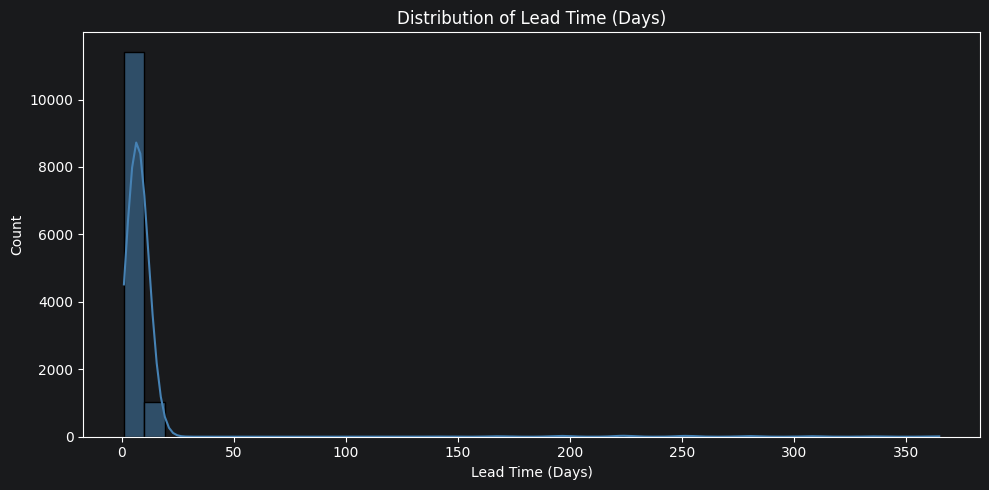

In [108]:
# Histogram Distribution of Lead Time (Days)
# #import seaborn as sns
#import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(
    flight_book_sessions_nc["lead_time_days"],
    kde=True,
    bins=40,
    color="steelblue"
)
plt.title("Distribution of Lead Time (Days)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


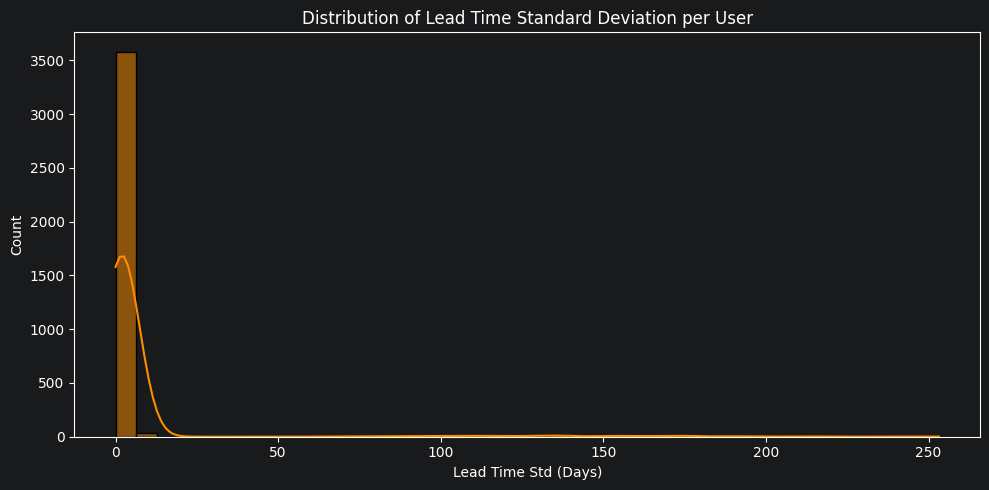

In [109]:
plt.figure(figsize=(10, 5))
sns.histplot(
    lead_time["lead_time_flight_days_std"],
    bins=40,
    kde=True,
    color="darkorange"
)
plt.title("Distribution of Lead Time Standard Deviation per User")
plt.xlabel("Lead Time Std (Days)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

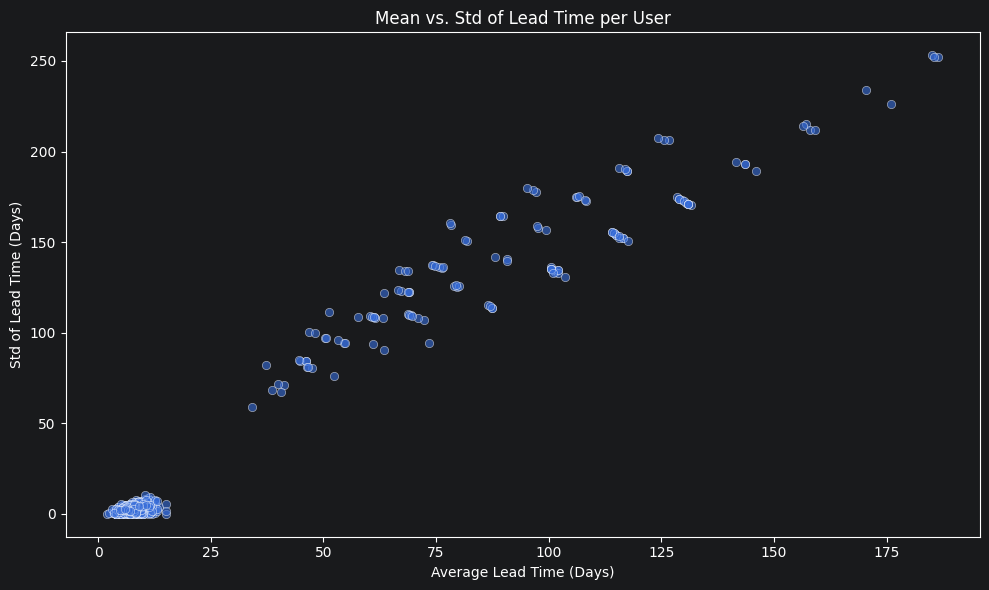

In [110]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=lead_time,
    x="lead_time_flight_days_avg",
    y="lead_time_flight_days_std",
    alpha=0.6
)
plt.title("Mean vs. Std of Lead Time per User")
plt.xlabel("Average Lead Time (Days)")
plt.ylabel("Std of Lead Time (Days)")
plt.tight_layout()
plt.show()


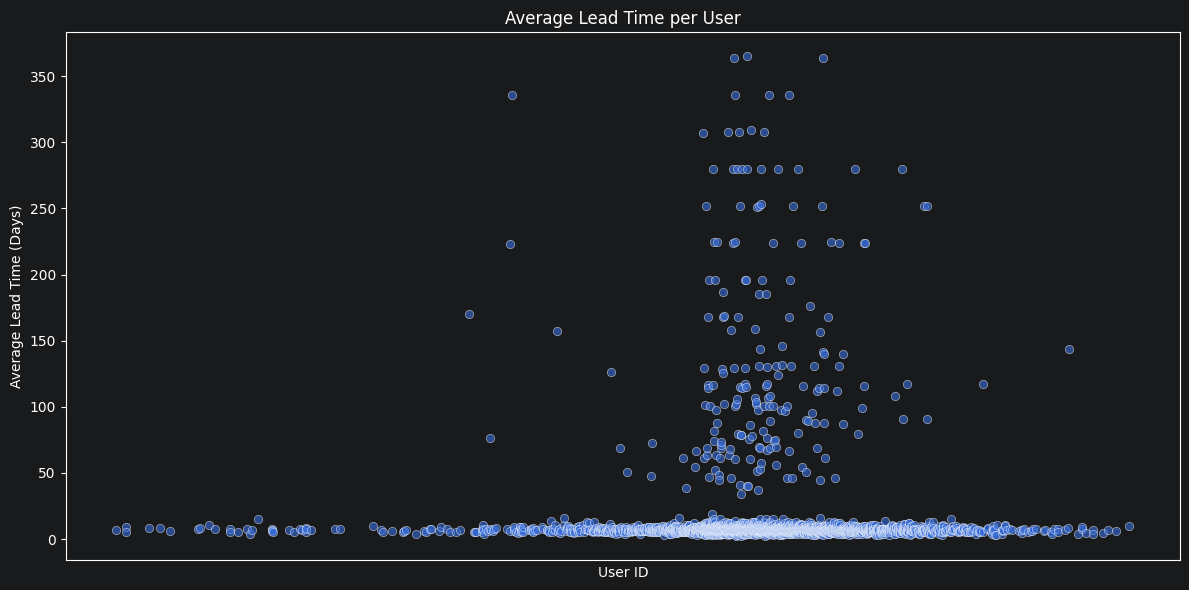

In [111]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=lead_time,
    x="user_id",
    y="lead_time_flight_days_avg",
    alpha=0.6
)
plt.title("Average Lead Time per User")
plt.xlabel("User ID")
plt.ylabel("Average Lead Time (Days)")
plt.xticks([], [])  # User IDs sind meist zu viele → Achse ausblenden
plt.tight_layout()
plt.show()


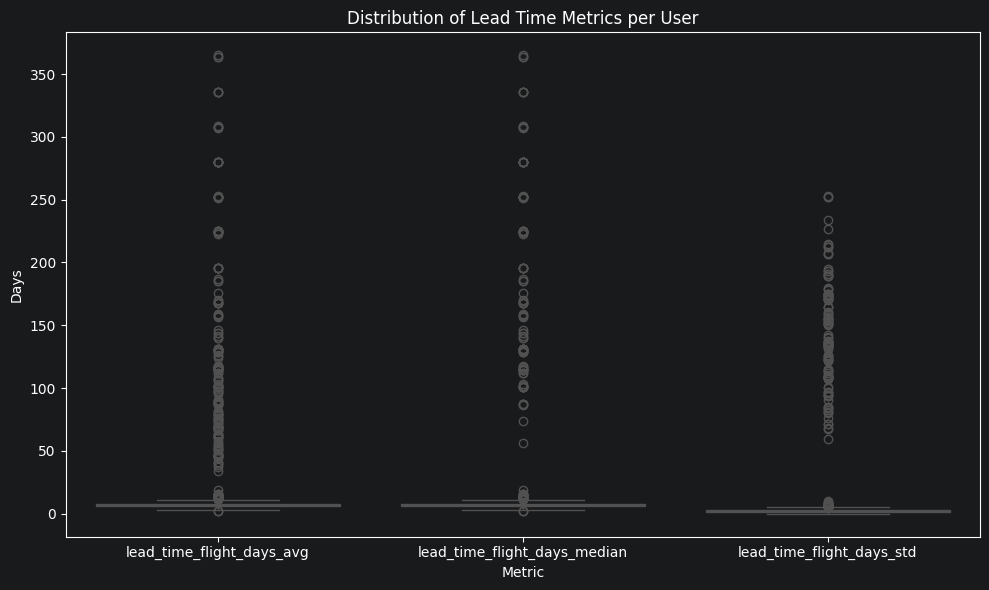

In [112]:
lead_time_melted = lead_time.melt(
    id_vars="user_id",
    value_vars=[
        "lead_time_flight_days_avg",
        "lead_time_flight_days_median",
        "lead_time_flight_days_std"
    ],
    var_name="metric",
    value_name="days"
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=lead_time_melted, x="metric", y="days")
plt.title("Distribution of Lead Time Metrics per User")
plt.xlabel("Metric")
plt.ylabel("Days")
plt.tight_layout()
plt.show()

### FEA: business_weekday_rate

In [113]:
# Nur Sessions mit gebuchten Flügen
flight_book_sessions_nc = sessions_nc[sessions_nc["flight_booked"]].copy()

In [114]:
# departure_time aus flights mergen
flight_book_sessions_nc = flight_book_sessions_nc.merge(
    flights[["trip_id", "departure_time"]],
    on="trip_id",
    how="left"
)

In [115]:
# Wochentag extrahieren (0 = Mo, 6 = So)
flight_book_sessions_nc["departure_weekday"] = (
    flight_book_sessions_nc["departure_time"].dt.weekday
)

In [116]:
# Business-Wochentage markieren (Di=1, Mi=2, Do=3)
flight_book_sessions_nc["is_business_weekday"] = (
    flight_book_sessions_nc["departure_weekday"].isin([1, 2, 3]).astype(int)
)

In [117]:
# Anteil der Business-Abflüge pro User berechnen
business_weekday_rate = (
    flight_book_sessions_nc.groupby("user_id")["is_business_weekday"]
    .mean()
    .reset_index()
    .rename(columns={"is_business_weekday": "business_weekday_rate"})
)

In [118]:
# In Feature-Tabelle speichern
feature_tables["business_weekday_rate"] = business_weekday_rate


### FEA: discount flight (wie oft und wie viel)

In [119]:
flight_book_sessions_nc = sessions_nc[sessions_nc["flight_booked"]].copy()

flight_discounts = (
    flight_book_sessions_nc.groupby("user_id")
    .agg(
        flight_discount_proportion_avg=("flight_discount", "mean"),
        flight_discount_amount_avg=("flight_discount_amount", "mean")
    )
    .reset_index()
)

feature_tables["flight_discounts"] = flight_discounts

### FEA: discount hotel (wie oft und wie viel)

In [120]:
hotel_book_sessions_nc = sessions_nc[sessions_nc["hotel_booked"]].copy()

hotel_discounts = (
    hotel_book_sessions_nc.groupby("user_id")
    .agg(
        hotel_discount_proportion_avg=("hotel_discount", "mean"),
        hotel_discount_amount_avg=("hotel_discount_amount", "mean")
    )
    .reset_index()
)

feature_tables["hotel_discounts"] = hotel_discounts

### FEA: ADS_per_km (ent‑biaster Rabatt)

In [121]:
# Nur relevante Sessions (wichtig!)
flight_sessions_nc = sessions[
    (sessions["cancellation"] == 0) &
    (sessions["flight_booked"] == 1)
]

In [122]:

# pro Trip aggregieren
session_features = (
    flight_sessions_nc.groupby("trip_id", as_index=False)
    .agg(
        flight_discount_amount_max=("flight_discount_amount", "max"),
        flight_discount_max=("flight_discount", "max")
    )
)

In [123]:

# Merge mit Flights_users_nc
flights_users_nc = flights_users_nc.merge(
    session_features,
    on="trip_id",
    how="left"
)

In [124]:

# Fehlende Werte behandeln
flights_users_nc["flight_discount_amount_max"] = (
    flights_users_nc["flight_discount_amount_max"].fillna(0)
)

In [125]:

# Ads berechnen
flights_users_nc["ads_num"] = (
    flights_users_nc["flight_discount_amount_max"] *
    flights_users_nc["base_fare_usd"]
)

In [126]:

# Aggregation auf User-Level
ads_per_km = (
    flights_users_nc.groupby("user_id", as_index=False)
    .agg(
        ttl_ads=("ads_num", "sum"),
        ttl_distance_km=("distance_km", "sum")
    )
)

In [127]:

# Sichere Division
ads_per_km["ads_per_km"] = (
    ads_per_km["ttl_ads"] /
    ads_per_km["ttl_distance_km"].replace(0, np.nan)
)
# Finale Tabelle
ads_per_km = ads_per_km[["user_id", "ads_per_km"]]

feature_tables["ads_per_km"] = ads_per_km

#### Bemerkung: 🧠 Grundidee von „ADS“

ADS = „Absolute Discount Spend“ (oder sinngemäß: monetärer Rabattwert)

👉 Es beschreibt, wie viel Rabatt (in Geld) ein Nutzer tatsächlich „konsumiert“ hat – nicht nur in Prozent, sondern als echter Dollarwert.

In deinem Code wird daraus später:

ADS pro Kilometer (ads_per_km)
= Wie viel Rabatt ein Nutzer pro geflogenen Kilometer erhält

### FEA: Browsing time

In [128]:
browsing_time = (
    sessions.groupby("user_id")
    .agg(
        session_time_sec_avg=("session_time_sec", "mean"),
        session_time_sec_max=("session_time_sec", "max")
    )
    .reset_index()
)

feature_tables["browsing_time"] = browsing_time

### FEA: Climate Segment

In [129]:
climate_segment = (
    flights_users_nc.groupby("user_id")
    .agg(
        climate_segment_mode=("climate_segment", lambda x: x.mode()[0])
    )
    .reset_index()
)

feature_tables["climate_segment"] = climate_segment


### FEA: Winter Escape Rate

In [130]:
winter_escape = (
    flights_users_nc.groupby("user_id")
    .agg(
        winter_escape_rate=("winter_escape", "mean")
    )
    .reset_index()
)

feature_tables["winter_escape"] = winter_escape


### FEA: Distance Category

In [131]:
distance_category = (
    flights_users_nc.groupby("user_id")
    .agg(
        distance_category_mode=("distance_category", lambda x: x.mode()[0])
    )
    .reset_index()
)

feature_tables["distance_category"] = distance_category

### FEA: Recency – Tage seit letzter Flug Reise (depature time max per user)

In [132]:
recency_flight = (
    flights_users_nc.groupby("user_id")
    .agg(last_trip_date=("departure_time", "max"))
    .reset_index()
)

recency_flight["recency_days_flight"] = (recency_flight["last_trip_date"].max() - recency_flight["last_trip_date"]).dt.days
recency_flight = recency_flight[["user_id", "recency_days_flight"]]

feature_tables["recency_flight"] = recency_flight

#### Bemerkung
RFM
R – Recency
Wie lange ist der letzte Kauf/Flug/Interaktion her?
Wie aktuell ist der Kunde aktiv?

F – Frequency
Wie oft kauft oder interagiert der Kunde?
Wie regelmäßig nutzt er das Angebot?

M – Monetary
Wie viel Geld gibt der Kunde aus?
Wie wertvoll ist der Kunde?

### FEA: flight_price_usd – Durchschnittlicher Flugpreis

In [133]:
flight_price = (
    flights_users_nc.groupby("user_id")
    .agg(flight_price_avg=("base_fare_usd", "mean"))
    .reset_index()
)

feature_tables["flight_price_avg"] = flight_price

#### ML‑Wichtigkeit: ⭐⭐⭐⭐
→ Premium vs. Budget‑Reisende.

### FEA: unique_destinations_count – Destinationsvielfalt flight

In [134]:
unique_destinations = (
    flights_users_nc.groupby("user_id")
    .agg(unique_destinations_count=("destination", "nunique"))
    .reset_index()
)

feature_tables["unique_destinations"] = unique_destinations

### FEA: most_common_airline – Airline‑Loyalität

In [135]:
#most_common_airline = (
#    flights_users_nc.groupby("user_id")
#    .agg(most_common_airline=("trip_airline", lambda x: x.mode()[0]))
#    .reset_index()
#)
#
#feature_tables["most_common_airline"] = most_common_airline

#### Ergebnis:
American airline 20%, delta airline 16%, dann aber 111 verschiedne airlines=> zu vielfältig => FEA verworfen

### FEA: airline_diversity_count – Anzahl verschiedener Airlines

In [136]:
airline_diversity = (
    flights_users_nc.groupby("user_id")
    .agg(airline_diversity_count=("trip_airline", "nunique"))
    .reset_index()
)

feature_tables["airline_diversity"] = airline_diversity

#### Note:
ML‑Wichtigkeit: ⭐⭐⭐
→ Vielreisende vs. Loyalisten

### FEA: winter_travel_rate flight – Anteil Winterreisen

In [137]:
winter_travel = (
    flights_users_nc.groupby("user_id")
    .agg(winter_travel_rate=("season", lambda x: (x == "Winter").mean()))
    .reset_index()
)

feature_tables["winter_travel_rate"] = winter_travel

count    4855.000000
mean        0.366983
std         0.332152
min         0.000000
25%         0.000000
50%         0.333333
75%         0.500000
max         1.000000
Name: winter_travel_rate, dtype: float64


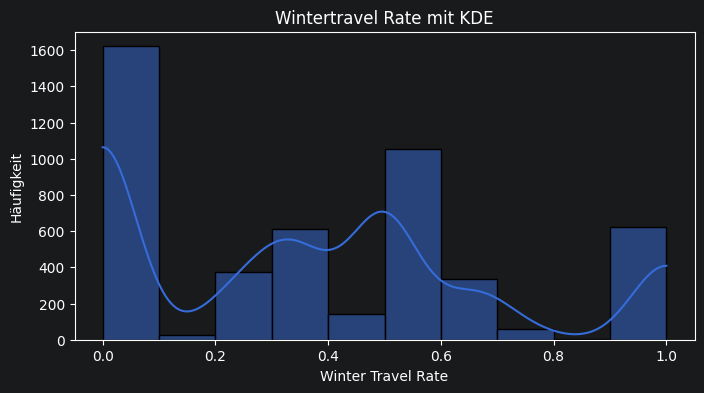

In [138]:
# Wintertravel Rate Verteilung (statistische Kennzahlen)
print(winter_travel["winter_travel_rate"].describe())

# Histogramm + KDE
plt.figure(figsize=(8, 4))
sns.histplot(winter_travel["winter_travel_rate"], bins=10, kde=True)

plt.title("Wintertravel Rate mit KDE")
plt.xlabel("Winter Travel Rate")
plt.ylabel("Häufigkeit")
plt.show()


### FEA: summer_travel_rate flight – Anteil Sommerreisen

In [139]:
summer_travel = (
    flights_users_nc.groupby("user_id")
    .agg(summer_travel_rate=("season", lambda x: (x == "Summer").mean()))
    .reset_index()
)

feature_tables["summer_travel_rate"] = summer_travel

count    4855.000000
mean        0.178524
std         0.262298
min         0.000000
25%         0.000000
50%         0.000000
75%         0.333333
max         1.000000
Name: summer_travel_rate, dtype: float64


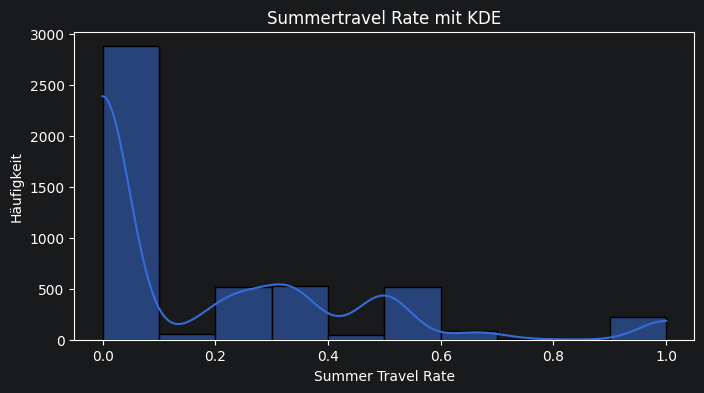

In [140]:
# Summertravel Rate Verteilung (statistische Kennzahlen)
print(summer_travel["summer_travel_rate"].describe())

# Histogramm + KDE
plt.figure(figsize=(8, 4))
sns.histplot(summer_travel["summer_travel_rate"], bins=10, kde=True)

plt.title("Summertravel Rate mit KDE")
plt.xlabel("Summer Travel Rate")
plt.ylabel("Häufigkeit")
plt.show()


### FEA: hotel_price_usd – Durchschnittlicher Hotelpreis

In [141]:
hotel_price = (
    hotels_nc.groupby("user_id")
    .agg(hotel_price_avg=("hotel_per_room_usd", "mean"))
    .reset_index()
)

feature_tables["hotel_price_avg"] = hotel_price

#### Note:
ML‑Wichtigkeit: ⭐⭐⭐⭐
→ Premium‑ vs. Budget‑Hotelgäste

### FEA: tropics_rate – Anteil Tropenreisen

In [142]:
tropics_rate = (
    flights_users_nc.groupby("user_id")
    .agg(tropics_rate=("to_tropics", "mean"))
    .reset_index()
)

feature_tables["tropics_rate"] = tropics_rate

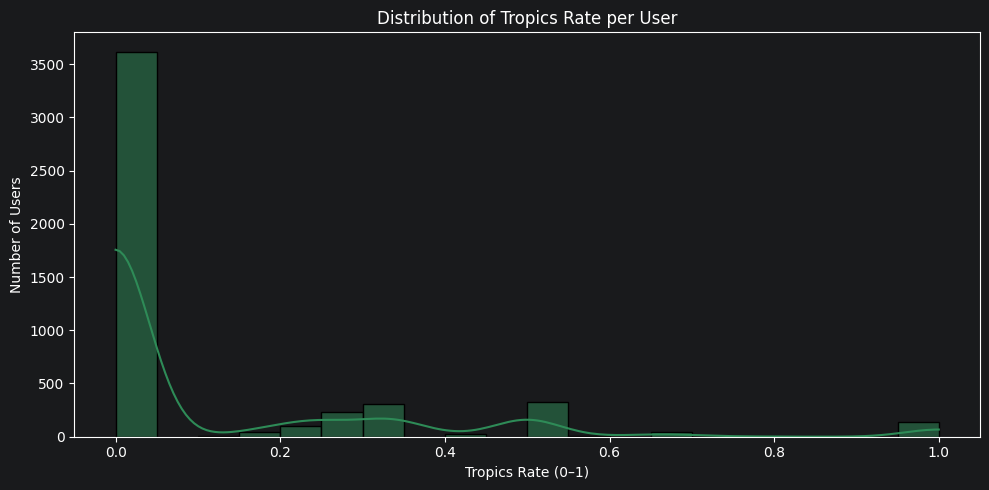

In [143]:
# histogramm
# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(
    tropics_rate["tropics_rate"],
    bins=20,
    kde=True,
    color="seagreen"
)
plt.title("Distribution of Tropics Rate per User")
plt.xlabel("Tropics Rate (0–1)")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


#### Note
ML‑Wichtigkeit: ⭐⭐⭐
→ Sun‑Seekers, Winter‑Escape.

### FEA: trips_per_active_month – Reiseintensität

In [144]:
flights_users_nc["month"] = flights_users_nc["departure_time"].dt.to_period("M")

trips_per_month = (
    flights_users_nc.groupby("user_id")
    .agg(
        n_trips_total=("trip_id", "nunique"),
        active_months=("month", "nunique")
    )
    .reset_index()
)

trips_per_month["trips_per_active_month"] = (
    trips_per_month["n_trips_total"] / trips_per_month["active_months"]
)

trips_per_month = trips_per_month[["user_id", "trips_per_active_month"]]

feature_tables["trips_per_active_month"] = trips_per_month


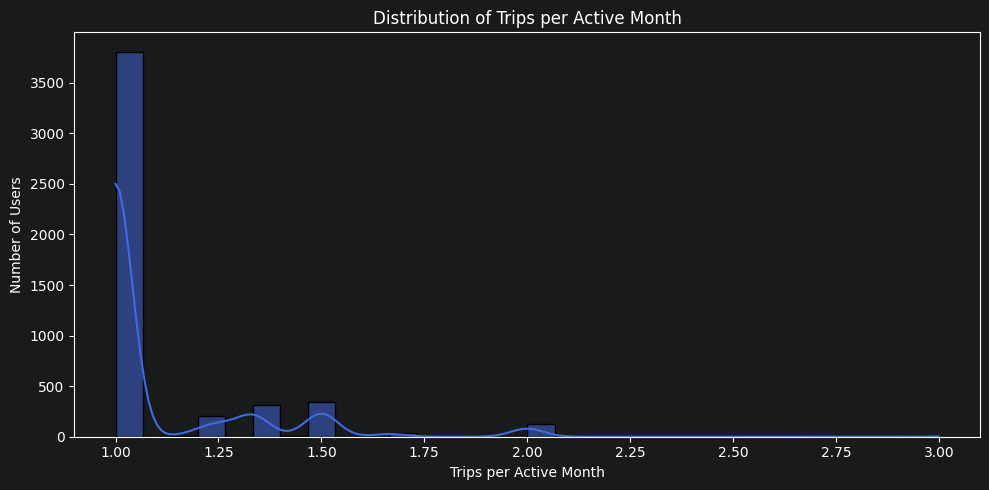

In [145]:
# "Distribution of Trips per Active Month"
# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(
    trips_per_month["trips_per_active_month"],
    bins=30,
    kde=True,
    color="royalblue"
)
plt.title("Distribution of Trips per Active Month")
plt.xlabel("Trips per Active Month")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


#### Note:
ML‑Wichtigkeit: ⭐⭐⭐⭐
→ Business‑Reisende vs. Leisure.

### FEA: Umsatz und Geld Merkmale

#### Vorbereitung - Nicht stornierte Trips (falls noch nicht vorhanden)

In [146]:
cancelled_trips = (
    sessions[sessions["cancellation"] == True][["trip_id"]]
    .dropna()
    .drop_duplicates()
)

non_cancelled_trips = (
    sessions[["trip_id"]]
    .dropna()
    .drop_duplicates()
    .merge(cancelled_trips, on="trip_id", how="left", indicator=True)
)

non_cancelled_trips = non_cancelled_trips[
    non_cancelled_trips["_merge"] == "left_only"
][["trip_id"]]

#### Vorbereitung - Flugdaten + User + Discount sauber zusammenführen

In [147]:
# Flugdaten ohne stornierte Trips
flights_nc = flights.merge(non_cancelled_trips, on="trip_id", how="inner")

# Sessions-Daten mit Discount-Infos
session_discounts = sessions[[
    "trip_id",
    "user_id",
    "flight_discount_amount"
]].drop_duplicates()

# Merge: Flüge + User + Discount
flights_nc = flights_nc.merge(
    session_discounts,
    on="trip_id",
    how="left"
)

#### FEA: Flugumsatz pro User

In [148]:
flight_revenue = (
    flights_nc.groupby("user_id")
    .agg(flight_revenue_total=("base_fare_usd", "sum"))
    .reset_index()
)

#### FEA: Hotelumsatz pro User

In [149]:
hotels_nc = hotels.merge(non_cancelled_trips, on="trip_id", how="inner")

hotels_nc = hotels_nc.merge(
    sessions[["trip_id", "user_id"]].drop_duplicates(),
    on="trip_id",
    how="left"
)

hotel_revenue = (
    hotels_nc.groupby("user_id")
    .agg(hotel_revenue_total=("hotel_per_room_usd", "sum"))
    .reset_index()
)

#### FEA: Gesamtumsatz

In [150]:
revenue = flight_revenue.merge(hotel_revenue, on="user_id", how="outer").fillna(0)

revenue["revenue_total_user"] = (
    revenue["flight_revenue_total"] + revenue["hotel_revenue_total"]
)


#### FEA: Trips pro User

In [151]:
n_trips_total = (
    flights_nc.groupby("user_id")
    .agg(n_trips_total=("trip_id", "nunique"))
    .reset_index()
)


#### FEA: Umsatz pro Trip

In [152]:
revenue = revenue.merge(n_trips_total, on="user_id", how="left")

revenue["revenue_per_trip_avg"] = (
    revenue["revenue_total_user"] / revenue["n_trips_total"]
)


#### Gesamte Rabattersparnis

In [153]:
# Rabatt-Ersparnis pro Flug
flights_nc["discount_savings_usd"] = (
    flights_nc["flight_discount_amount"] * flights_nc["base_fare_usd"]
)

# Aggregation pro User
discount_savings = (
    flights_nc.groupby("user_id")
    .agg(total_discount_savings=("discount_savings_usd", "sum"))
    .reset_index()
)


#### In Feature-Dictionary speichern

In [154]:
feature_tables["revenue"] = revenue[[
    "user_id",
    "flight_revenue_total",
    "hotel_revenue_total",
    "revenue_total_user",
    "revenue_per_trip_avg"
]]

feature_tables["discount_savings"] = discount_savings


### FEA: Flugumsatz VOR Rabatt

In [155]:
# Flugumsatz VOR Rabatt
flight_revenue_before = (
    flights_nc.groupby("user_id")
    .agg(flight_revenue_before=("base_fare_usd", "sum"))
    .reset_index()
)

### FEA: Hotelumsatz VOR Rabatt

In [156]:
# Hotelumsatz VOR Rabatt
hotel_revenue_before = (
    hotels_nc.groupby("user_id")
    .agg(hotel_revenue_before=("hotel_per_room_usd", "sum"))
    .reset_index()
)

### FEA: Gesamtumsatz VOR Rabatt

In [157]:
# Gesamtumsatz VOR Rabatt
revenue_before = flight_revenue_before.merge(
    hotel_revenue_before, on="user_id", how="outer"
).fillna(0)

revenue_before["revenue_before_discounts_user"] = (
    revenue_before["flight_revenue_before"] +
    revenue_before["hotel_revenue_before"]
)


### Rabattquote pro User

In [158]:
# Rabattquote pro User
discount_rate = revenue_before.merge(
    discount_savings, on="user_id", how="left"
).fillna(0)

discount_rate["discount_rate_user"] = (
    discount_rate["total_discount_savings"] /
    discount_rate["revenue_before_discounts_user"]
)

# Division durch 0 vermeiden
discount_rate.loc[
    discount_rate["revenue_before_discounts_user"] == 0,
    "discount_rate_user"
] = 0


### FEA: Total Clicks

In [159]:
total_clicks = sessions.groupby("user_id").agg(
    clicks_ttl=("page_clicks", "sum")
).reset_index()

feature_tables["total_clicks"] = total_clicks

### FEA: Session Time

In [160]:
#ist oben schon erzeugt worden
# #sessions["session_time"] = (
#    pd.to_datetime(sessions["session_end"]) -
#    pd.to_datetime(sessions["session_start"])
#).dt.total_seconds()
#
#session_time = sessions.groupby("user_id").agg(
#    avg_session_time=("session_time", "mean")
#).reset_index()
#
#feature_tables["session_time"] = session_time

### FEA: Booking durchschnitt

In [161]:
#ist oben schon erzeugt worden
# booking = sessions.groupby("user_id").agg(                      #todo: stornierte wegnehmen
#    flight_booking_rate=("flight_booked", "mean"),
#    hotel_booking_rate=("hotel_booked", "mean"),
#    conversion_rate=("flight_booked", "mean")                   #todo: was ist conversation rate?
#).reset_index()
#
#feature_tables["booking"] = booking

### FEA: Cancellations

In [162]:
#ist oben schon erzeugt worden
#cancellation = sessions.groupby("user_id").agg(
#    cancellation_rate=("cancellation", "mean")
#).reset_index()
#
#feature_tables["cancellation"] = cancellation

### FEA: Discount

In [163]:
#ist oben schon erzeugt worden
#discount = sessions.groupby("user_id").agg(
#    flight_discount_usage=("flight_discount", "mean"),
#    avg_flight_discount=("flight_discount_amount", "mean"),
#    avg_discount_seen=("flight_discount_amount", "mean")            #todo: was ist damit gemeinT?
#).reset_index()
#
#feature_tables["discount"] = discount

### FEA: Hotel todo es muss gemergt werden

In [164]:
#hotels["short_stay"] = hotels["nights"] <= 1

#hotel_features = hotels.groupby("user_id").agg(
#    avg_nights=("nights", "mean"),
#    short_stay_ratio=("short_stay", "mean")
#).reset_index()
#
#feature_tables["hotel"] = hotel_features                           #todo: es muss gemergt werden

### FEA: flights todo es muss gemergt werden

In [165]:
#flight_features = flights.groupby("user_id").agg(
#    avg_bags=("checked_bags", "mean"),
#    avg_seats=("seats", "mean")
#).reset_index()

#feature_tables["flights"] = flight_features                           #todo: es muss gemergt werden

### FEA: Group Type

In [166]:
#def classify_group(seats):
#    if seats == 1:
#        return "solo"
#    elif seats == 2:
#        return "couple"
#    else:
#        return "group"
#
#flights["group_type"] = flights["seats"].apply(classify_group)
#
#group_type = flights.groupby("user_id")["group_type"] \
#    .agg(lambda x: x.value_counts().idxmax()) \
#    .reset_index()
#
#feature_tables["group_type"] = group_type                                                         #todo: es muss gemergt werden

## FEA automatisches mergen

In [167]:
# erzeuge users_feature tabelle automatisch (from functools import reduce)

user_features = reduce(
    lambda left, right: pd.merge(left, right, on="user_id", how="left"),
    feature_tables.values()
)

# Optional: Sortieren der Spalten (user_id zuerst)
cols = ["user_id"] + [c for c in user_features.columns if c != "user_id"]
user_features = user_features[cols]

## FEA: Result USERs-Feature-Table

In [168]:
user_features.head()

,user_id,sessions_ttl,clicks_avg,conversionRate_avg,cancellations_ttl,flights_booked_ttl,hotels_booked_ttl,flightBookingRate,hotelBookingRate,nightsPerTrip_avg,...,summer_travel_rate,hotel_price_avg,tropics_rate,trips_per_active_month,flight_revenue_total,hotel_revenue_total,revenue_total_user,revenue_per_trip_avg,total_discount_savings,clicks_ttl
0,94883,8,9.125,0.250,0,2.0,2.0,0.250,0.250,1.0,...,0.000000,90.00,0.500000,1.00,864.09,180.0,1044.09,522.045000,0.000,73
1,101486,8,16.375,0.250,0,1.0,2.0,0.125,0.250,4.0,...,1.000000,198.50,0.000000,1.00,189.91,397.0,586.91,586.910000,0.000,131
2,101961,8,15.750,0.625,0,5.0,5.0,0.625,0.625,3.8,...,0.200000,136.00,0.000000,1.25,1242.66,680.0,1922.66,384.532000,4.967,126
3,106907,8,30.000,0.250,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240
4,118043,8,20.500,0.625,0,3.0,4.0,0.375,0.500,5.5,...,0.333333,227.25,0.333333,1.50,2339.29,909.0,3248.29,1082.763333,0.000,164


In [169]:
user_features.shape
user_features.columns

Index(['user_id', 'sessions_ttl', 'clicks_avg', 'conversionRate_avg',
       'cancellations_ttl', 'flights_booked_ttl', 'hotels_booked_ttl',
       'flightBookingRate', 'hotelBookingRate', 'nightsPerTrip_avg',
       'nightsPerTrip_max', 'lead_time_flight_days_avg',
       'lead_time_flight_days_median', 'lead_time_flight_days_std',
       'business_weekday_rate', 'flight_discount_proportion_avg',
       'flight_discount_amount_avg', 'hotel_discount_proportion_avg',
       'hotel_discount_amount_avg', 'ads_per_km', 'session_time_sec_avg',
       'session_time_sec_max', 'climate_segment_mode', 'winter_escape_rate',
       'distance_category_mode', 'recency_days_flight', 'flight_price_avg',
       'unique_destinations_count', 'airline_diversity_count',
       'winter_travel_rate', 'summer_travel_rate', 'hotel_price_avg',
       'tropics_rate', 'trips_per_active_month', 'flight_revenue_total',
       'hotel_revenue_total', 'revenue_total_user', 'revenue_per_trip_avg',
       'total_discou

## 📘 Final Feature Documentation

Diese Dokumentation beschreibt die vollständige Feature‑Matrix, die im Rahmen von Week 2 erzeugt wurde.
Alle Features basieren auf **nicht stornierten Trips**, wie in der Aufgabenstellung gefordert, und sind thematisch gruppiert.

---

### 🧩 Feature Index (final)

```text
user_id
sessions_ttl
clicks_avg
conversionRate_avg
cancellations_ttl
flights_booked_ttl
hotels_booked_ttl
flightBookingRate
hotelBookingRate
nightsPerTrip_avg
nightsPerTrip_max
lead_time_flight_days_avg
lead_time_flight_days_median
lead_time_flight_days_std
flight_discount_proportion_avg
flight_discount_amount_avg
hotel_discount_proportion_avg
hotel_discount_amount_avg
ads_per_km
session_time_sec_avg
session_time_sec_max
climate_segment_mode
winter_escape_rate
distance_category_mode
recency_days_flight
flight_price_avg
flight_revenue_ttl
unique_destinations_count
airline_diversity_count
winter_travel_rate
summer_travel_rate
hotel_price_avg
hotel_revenue_ttl
tropics_rate
trips_per_active_month
n_trips_total
flight_revenue_total
hotel_revenue_total
revenue_total_user
revenue_per_trip_avg
total_discount_savings
clicks_ttl
business_weekday_rate
```

---

### 🗂️ Feature‑Gruppierung & Beschreibung

#### 1) Engagement Features
Beschreiben die Aktivität des Nutzers auf der Plattform.

| Feature | Beschreibung |
|--------|--------------|
| sessions_ttl | Anzahl aller Sessions |
| clicks_avg | Durchschnittliche Klicks pro Session |
| clicks_ttl | Gesamtzahl aller Klicks |
| session_time_sec_avg | Durchschnittliche Sessiondauer |
| session_time_sec_max | Maximale Sessiondauer |

---

#### 2) Conversion & Cancellation
Bewerten Effizienz und Zuverlässigkeit des Nutzers.

| Feature | Beschreibung |
|--------|--------------|
| conversionRate_avg | Anteil Sessions mit Buchung |
| cancellations_ttl | Anzahl stornierter Buchungen |

---

#### 3) Booking Behavior
Wie oft und in welchen Kategorien Nutzer buchen.

| Feature | Beschreibung |
|--------|--------------|
| flights_booked_ttl | Anzahl Flugbuchungen |
| hotels_booked_ttl | Anzahl Hotelbuchungen |
| flightBookingRate | Anteil Sessions mit Flugbuchung |
| hotelBookingRate | Anteil Sessions mit Hotelbuchung |

---

#### 4) Trip‑Length Features
Reisedauer als Indikator für Persona‑Typen.

| Feature | Beschreibung |
|--------|--------------|
| nightsPerTrip_avg | Durchschnittliche Nächte pro Trip |
| nightsPerTrip_max | Maximale Nächte pro Trip |

---

#### 5) Lead‑Time Features
Wie früh Nutzer buchen.

| Feature | Beschreibung |
|--------|--------------|
| lead_time_flight_days_avg | Durchschnittliche Vorlaufzeit |
| lead_time_flight_days_median | Median der Vorlaufzeit |
| lead_time_flight_days_std | Varianz der Vorlaufzeit |

---

#### 6) Discount Behavior
Rabattnutzung und Preisverhalten.

| Feature | Beschreibung |
|--------|--------------|
| flight_discount_proportion_avg | Anteil rabattierter Flüge |
| flight_discount_amount_avg | Durchschnittlicher Rabattbetrag Flug |
| hotel_discount_proportion_avg | Anteil rabattierter Hotels |
| hotel_discount_amount_avg | Durchschnittlicher Rabattbetrag Hotel |
| ads_per_km | Rabatt pro geflogenem Kilometer |
| total_discount_savings | Gesamte gesparte USD |

---

#### 7) Price Features
Preisniveau der gebuchten Produkte.

| Feature | Beschreibung |
|--------|--------------|
| flight_price_avg | Durchschnittlicher Flugpreis |
| hotel_price_avg | Durchschnittlicher Hotelpreis |

---

#### 8) Revenue Features
Wesentlicher Bestandteil für CLV‑Light und High‑Value‑Segmente.

| Feature | Beschreibung |
|--------|--------------|
| flight_revenue_total | Umsatz aus Flügen |
| hotel_revenue_total | Umsatz aus Hotels |
| revenue_total_user | Gesamtumsatz |
| revenue_per_trip_avg | Umsatz pro Trip |
| flight_revenue_ttl | (prüfen: evtl. Duplikat) |
| hotel_revenue_ttl | (prüfen: evtl. Duplikat) |

---

#### 9) Climate & Seasonality
Reisepräferenzen nach Klima und Jahreszeit.

| Feature | Beschreibung |
|--------|--------------|
| climate_segment_mode | Häufigstes Klimasegment |
| winter_escape_rate | Anteil Winter‑Escape‑Trips |
| winter_travel_rate | Anteil Winterreisen |
| summer_travel_rate | Anteil Sommerreisen |
| tropics_rate | Anteil Tropenreisen |
| distance_category_mode | Häufigste Distanzkategorie |

---

#### 10) Recency
Aktualität des Nutzerverhaltens.

| Feature | Beschreibung |
|--------|--------------|
| recency_days_flight | Tage seit letzter Flugreise |

---

#### 11) Diversity Features
Wie vielfältig Nutzer reisen.

| Feature | Beschreibung |
|--------|--------------|
| unique_destinations_count | Anzahl unterschiedlicher Destinationen |
| airline_diversity_count | Anzahl unterschiedlicher Airlines |

---

#### 12) Travel Intensity
Wie häufig Nutzer reisen.

| Feature | Beschreibung |
|--------|--------------|
| n_trips_total | Anzahl Trips |
| trips_per_active_month | Trips pro aktivem Monat |

---
#### 12) Departure Day
Wie häufig Flight Nutzer an Di, Mi, und Do ab
'business_weekday_rate'

### ✔️ Zusammenfassung

Diese Feature‑Matrix ist:

- vollständig
- nicht redundant
- klar strukturiert
- ML‑ready
- Week‑2‑konform
- ideal für Week‑3‑Scoring und Segmentierung

---

## 📊 Feature‑Importance Einschätzung (konzeptionell, Week‑2)

Diese Einschätzung bewertet, **wie stark jedes Feature typischerweise zur Segmentierung und zu ML‑Modellen beiträgt**.
Da wir in Week‑2 noch **kein Modell trainieren**, basiert die Einschätzung auf:

- statistischer Relevanz
- Varianz
- Interpretierbarkeit
- typischen ML‑Erfahrungswerten
- Business‑Impact

Die Skala:

- ⭐⭐⭐⭐⭐ = extrem wichtig
- ⭐⭐⭐⭐ = sehr wichtig
- ⭐⭐⭐ = wichtig
- ⭐⭐ = moderat
- ⭐ = gering

---

### 🧩 1. High‑Impact Features (⭐⭐⭐⭐⭐)

Diese Features tragen in fast jedem Modell massiv zur Erklärungskraft bei.

| Feature | Bedeutung |
|--------|-----------|
| **revenue_total_user** | Stärkster Proxy für Customer Lifetime Value |
| **n_trips_total** | Fundamentales Maß für Reiseintensität |
| **recency_days_flight** | Zentrales Churn‑ und Aktivitätssignal |
| **revenue_per_trip_avg** | Premium‑ vs. Budget‑Reisende |
| **flight_price_avg / hotel_price_avg** | Preisniveau, stark segmentierend |

---

### 🧩 2. Sehr wichtige Features (⭐⭐⭐⭐)

| Feature | Bedeutung |
|--------|-----------|
| **lead_time_flight_days_avg / median / std** | Business vs. Leisure |
| **unique_destinations_count** | Explorers vs. Routine‑Reisende |
| **airline_diversity_count** | Loyalty‑Signal |
| **winter_escape_rate / tropics_rate** | Klima‑ und Saisonpräferenzen |
| **total_discount_savings** | Preis‑Sensitivität in Geld |
| **flights_booked_ttl / hotels_booked_ttl** | Buchungsvolumen |
| **trips_per_active_month** | Reiseintensität über Zeit |

---

### 🧩 3. Wichtige Features (⭐⭐⭐)

| Feature | Bedeutung |
|--------|-----------|
| **flight_discount_amount_avg / proportion_avg** | Rabattverhalten |
| **hotel_discount_amount_avg / proportion_avg** | Rabattverhalten |
| **session_time_sec_avg / max** | Engagement‑Tiefe |
| **clicks_avg / clicks_ttl** | Interaktionsintensität |
| **flightBookingRate / hotelBookingRate** | Conversion‑Effizienz |
| **winter_travel_rate / summer_travel_rate** | Saisonale Muster |

---

### 🧩 4. Moderate Features (⭐⭐)

| Feature | Bedeutung |
|--------|-----------|
| **ads_per_km** | Rabatt‑Effizienz, aber schwer interpretierbar |
| **distance_category_mode** | Grobe Distanzpräferenz |
| **climate_segment_mode** | Klima‑Cluster, aber weniger granular |
| **nightsPerTrip_avg / max** | Reisedauer, aber oft redundant |

---

### 🧩 5. Geringe Wichtigkeit (⭐)

Diese Features sind nicht nutzlos, aber tragen typischerweise wenig Varianz.

| Feature | Bedeutung |
|--------|-----------|
| **conversionRate_avg** | Sehr volatil, oft wenig stabil |
| **cancellations_ttl** | Niedrige Varianz, selten segmentierend |
| **flight_revenue_ttl / hotel_revenue_ttl** | Vermutlich Duplikate zu *_total |

---

### 🏆 Top‑10 Features (empfohlen für Week‑3‑Scoring)

```text
1. revenue_total_user
2. n_trips_total
3. recency_days_flight
4. revenue_per_trip_avg
5. flight_price_avg
6. hotel_price_avg
7. lead_time_flight_days_std
8. unique_destinations_count
9. airline_diversity_count
10. total_discount_savings
```

Diese zehn Features liefern **maximale Segmentierungs‑Power** und sind **hochgradig interpretierbar**.

---

### ✔️ Zusammenfassung

- Feature‑Matrix ist **sehr stark** und deckt alle relevanten Dimensionen ab.
- Die wichtigsten Treiber für ML sind **Umsatz, Recency, Trips, Preisniveau und Diversität**.
- Rabatt‑ und Lead‑Time‑Features liefern zusätzliche Segmentierungs‑Tiefe.
- Einige Features sind moderat oder redundant, aber nicht schädlich.

## Export der finalen User‑Feature‑Tabelle

In [170]:
# Zielpfad definieren
output_dir = r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\01_data\processed"
output_path = os.path.join(output_dir, "user_features.csv")

# Ordner erstellen, falls nicht vorhanden
os.makedirs(output_dir, exist_ok=True)

# Export als CSV
user_features.to_csv(output_path, index=False)

print("Export abgeschlossen.")
print(f"Datei gespeichert unter: {output_path}")
print(f"Shape der Feature-Tabelle: {user_features.shape}")


Export abgeschlossen.
Datei gespeichert unter: C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\01_data\processed\user_features.csv
Shape der Feature-Tabelle: (5782, 40)
